In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [9]:
import kagglehub
import os
import pandas as pd

# Download the dataset
path = kagglehub.dataset_download("jr2ngb/superstore-data")

print("Dataset path:", path)
print("\nFiles available in dataset:")

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

100%|██████████████████████████████████████████████████████████████████████████████| 2.74M/2.74M [00:05<00:00, 543kB/s]

Extracting files...
Dataset path: C:\Users\dell\.cache\kagglehub\datasets\jr2ngb\superstore-data\versions\1

Files available in dataset:
C:\Users\dell\.cache\kagglehub\datasets\jr2ngb\superstore-data\versions\1\superstore_dataset2011-2015.csv


In [12]:
import pandas as pd

# CSV file path
file_path = r"C:\Users\dell\.cache\kagglehub\datasets\jr2ngb\superstore-data\versions\1\superstore_dataset2011-2015.csv"

# Load CSV with compatible encoding
df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(51290, 24)

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [13]:
# ============================================
# STEP 2: DATASET STRUCTURE & QUALITY CHECK
# ============================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# ------------------------------------------------

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# ------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

# ------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing %": (missing_values.values / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

if missing_values.sum() == 0:
    print("No missing values found.")

# ------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

# ------------------------------------------------

print("\n" + "=" * 60)
print("NUMERICAL COLUMNS")
print("=" * 60)

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print(numerical_columns)

# ------------------------------------------------

print("\n" + "=" * 60)
print("CATEGORICAL / OBJECT COLUMNS")
print("=" * 60)

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print(categorical_columns)

# ------------------------------------------------

print("\n" + "=" * 60)
print("SALES SUMMARY")
print("=" * 60)

print(df["Sales"].describe())

# ------------------------------------------------

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)

print("Order Date:")
print("Minimum:", df["Order Date"].min())
print("Maximum:", df["Order Date"].max())

print("\nShip Date:")
print("Minimum:", df["Ship Date"].min())
print("Maximum:", df["Ship Date"].max())

# ------------------------------------------------

print("\n" + "=" * 60)
print("UNIQUE VALUES")
print("=" * 60)

print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())
print("Unique Categories:", df["Category"].nunique())
print("Unique Sub-Categories:", df["Sub-Category"].nunique())
print("Unique Countries:", df["Country"].nunique())

DATASET INFORMATION

Dataset Shape:
(51290, 24)

Number of Rows: 51290
Number of Columns: 24

COLUMN NAMES
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. City
10. State
11. Country
12. Postal Code
13. Market
14. Region
15. Product ID
16. Category
17. Sub-Category
18. Product Name
19. Sales
20. Quantity
21. Discount
22. Profit
23. Shipping Cost
24. Order Priority

DATA TYPES
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit          

,Column,Missing Values,Missing %
11,Postal Code,41296,80.51



DUPLICATE ROWS
Duplicate rows: 0

NUMERICAL COLUMNS
['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

CATEGORICAL / OBJECT COLUMNS
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Order Priority']

SALES SUMMARY
count    51290.000000
mean       246.490581
std        487.565361
min          0.444000
25%         30.758625
50%         85.053000
75%        251.053200
max      22638.480000
Name: Sales, dtype: float64

DATE RANGE
Order Date:
Minimum: 1/1/2011
Maximum: 9/9/2014

Ship Date:
Minimum: 1/1/2012
Maximum: 9/9/2014

UNIQUE VALUES
Unique Orders: 25035
Unique Customers: 1590
Unique Products: 10292
Unique Categories: 3
Unique Sub-Categories: 17
Unique Countries: 147


In [20]:
# ============================================
# DATE SANITY CHECK
# ============================================

check_df = df.copy()

# Parse both possible interpretations
check_df["Order_MDY"] = pd.to_datetime(
    check_df["Order Date"],
    format="mixed",
    errors="coerce"
)

check_df["Ship_MDY"] = pd.to_datetime(
    check_df["Ship Date"],
    format="mixed",
    errors="coerce"
)

check_df["Order_DMY"] = pd.to_datetime(
    check_df["Order Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

check_df["Ship_DMY"] = pd.to_datetime(
    check_df["Ship Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)


# ------------------------------------------------
# Calculate shipping duration
# ------------------------------------------------

check_df["Ship_Days_MDY"] = (
    check_df["Ship_MDY"] - check_df["Order_MDY"]
).dt.days

check_df["Ship_Days_DMY"] = (
    check_df["Ship_DMY"] - check_df["Order_DMY"]
).dt.days


print("=" * 60)
print("DATE INTERPRETATION SANITY CHECK")
print("=" * 60)


# ------------------------------------------------
# Compare invalid shipping dates
# ------------------------------------------------

print("\nInvalid Ship Dates under MM/DD/YYYY:")
print(
    (check_df["Ship_Days_MDY"] < 0).sum()
)

print("\nInvalid Ship Dates under DD/MM/YYYY:")
print(
    (check_df["Ship_Days_DMY"] < 0).sum()
)


# ------------------------------------------------
# Compare shipping duration statistics
# ------------------------------------------------

print("\n" + "=" * 60)
print("SHIPPING DURATION - MM/DD/YYYY")
print("=" * 60)

print(
    check_df["Ship_Days_MDY"].describe()
)


print("\n" + "=" * 60)
print("SHIPPING DURATION - DD/MM/YYYY")
print("=" * 60)

print(
    check_df["Ship_Days_DMY"].describe()
)


# ------------------------------------------------
# Check realistic shipping durations
# ------------------------------------------------

print("\n" + "=" * 60)
print("REALISTIC SHIPPING DAYS")
print("=" * 60)

print("\nMM/DD/YYYY:")
print(
    check_df.loc[
        check_df["Ship_Days_MDY"].between(0, 30),
        "Ship_Days_MDY"
    ].describe()
)

print("\nDD/MM/YYYY:")
print(
    check_df.loc[
        check_df["Ship_Days_DMY"].between(0, 30),
        "Ship_Days_DMY"
    ].describe()
)


# ------------------------------------------------
# Show problematic examples
# ------------------------------------------------

print("\n" + "=" * 60)
print("MM/DD/YYYY PROBLEMATIC EXAMPLES")
print("=" * 60)

display(
    check_df[
        check_df["Ship_Days_MDY"] < 0
    ][
        [
            "Order Date",
            "Ship Date",
            "Order_MDY",
            "Ship_MDY",
            "Order_DMY",
            "Ship_DMY",
            "Ship_Days_MDY",
            "Ship_Days_DMY",
            "Ship Mode"
        ]
    ].head(20)
)


print("\n" + "=" * 60)
print("DD/MM/YYYY PROBLEMATIC EXAMPLES")
print("=" * 60)

display(
    check_df[
        check_df["Ship_Days_DMY"] < 0
    ][
        [
            "Order Date",
            "Ship Date",
            "Order_MDY",
            "Ship_MDY",
            "Order_DMY",
            "Ship_DMY",
            "Ship_Days_MDY",
            "Ship_Days_DMY",
            "Ship Mode"
        ]
    ].head(20)
)

DATE INTERPRETATION SANITY CHECK

Invalid Ship Dates under MM/DD/YYYY:
9687

Invalid Ship Dates under DD/MM/YYYY:
0

SHIPPING DURATION - MM/DD/YYYY
count    51290.000000
mean         5.079041
std         97.771493
min       -322.000000
25%          1.000000
50%          4.000000
75%         59.000000
max        214.000000
Name: Ship_Days_MDY, dtype: float64

SHIPPING DURATION - DD/MM/YYYY
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Ship_Days_DMY, dtype: float64

REALISTIC SHIPPING DAYS

MM/DD/YYYY:
count    27279.000000
mean         4.001576
std          3.412319
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         30.000000
Name: Ship_Days_MDY, dtype: float64

DD/MM/YYYY:
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
7

,Order Date,Ship Date,Order_MDY,Ship_MDY,Order_DMY,Ship_DMY,Ship_Days_MDY,Ship_Days_DMY,Ship Mode
1512,6/1/2011,13-01-2011,2011-06-01,2011-01-13,2011-01-06,2011-01-13,-139,7,Standard Class
1514,6/1/2011,13-01-2011,2011-06-01,2011-01-13,2011-01-06,2011-01-13,-139,7,Standard Class
1517,6/1/2011,13-01-2011,2011-06-01,2011-01-13,2011-01-06,2011-01-13,-139,7,Standard Class
1794,7/2/2011,13-02-2011,2011-07-02,2011-02-13,2011-02-07,2011-02-13,-139,6,Standard Class
1795,7/2/2011,14-02-2011,2011-07-02,2011-02-14,2011-02-07,2011-02-14,-138,7,Standard Class
1799,7/2/2011,13-02-2011,2011-07-02,2011-02-13,2011-02-07,2011-02-13,-139,6,Standard Class
1817,7/3/2011,14-03-2011,2011-07-03,2011-03-14,2011-03-07,2011-03-14,-111,7,Standard Class
1818,7/3/2011,14-03-2011,2011-07-03,2011-03-14,2011-03-07,2011-03-14,-111,7,Standard Class
1829,7/4/2011,13-04-2011,2011-07-04,2011-04-13,2011-04-07,2011-04-13,-82,6,Standard Class
1833,7/4/2011,13-04-2011,2011-07-04,2011-04-13,2011-04-07,2011-04-13,-82,6,Standard Class



DD/MM/YYYY PROBLEMATIC EXAMPLES


,Order Date,Ship Date,Order_MDY,Ship_MDY,Order_DMY,Ship_DMY,Ship_Days_MDY,Ship_Days_DMY,Ship Mode


In [23]:
# ============================================
# STEP 3: FINAL DATA CLEANING - CORRECTED
# ============================================

sales_df = df.copy()

print("=" * 60)
print("STEP 3: FINAL DATA CLEANING")
print("=" * 60)

print("\nOriginal Dataset Shape:")
print(sales_df.shape)


# ------------------------------------------------
# 1. NORMALIZE DATE SEPARATORS
# ------------------------------------------------

sales_df["Order Date"] = (
    sales_df["Order Date"]
    .astype(str)
    .str.replace("-", "/", regex=False)
    .str.strip()
)

sales_df["Ship Date"] = (
    sales_df["Ship Date"]
    .astype(str)
    .str.replace("-", "/", regex=False)
    .str.strip()
)


# ------------------------------------------------
# 2. CONVERT DATES USING DD/MM/YYYY
# ------------------------------------------------

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    format="%d/%m/%Y",
    errors="coerce"
)


# ------------------------------------------------
# 3. DATE CONVERSION CHECK
# ------------------------------------------------

print("\n" + "=" * 60)
print("DATE CONVERSION CHECK")
print("=" * 60)

print("\nOrder Date:")
print("Minimum:", sales_df["Order Date"].min())
print("Maximum:", sales_df["Order Date"].max())

print("\nShip Date:")
print("Minimum:", sales_df["Ship Date"].min())
print("Maximum:", sales_df["Ship Date"].max())

invalid_order_dates = sales_df["Order Date"].isna().sum()
invalid_ship_dates = sales_df["Ship Date"].isna().sum()

print("\nInvalid Order Dates:", invalid_order_dates)
print("Invalid Ship Dates:", invalid_ship_dates)


# ------------------------------------------------
# 4. CREATE SHIPPING DAYS
# ------------------------------------------------

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days


# ------------------------------------------------
# 5. SHIPPING DURATION CHECK
# ------------------------------------------------

invalid_shipping_days = (
    sales_df["Shipping Days"] < 0
).sum()

print("\n" + "=" * 60)
print("SHIPPING DURATION CHECK")
print("=" * 60)

print("\nInvalid Shipping Durations:", invalid_shipping_days)

print("\nShipping Days Summary:")
print(sales_df["Shipping Days"].describe())


# ------------------------------------------------
# 6. MISSING VALUES
# ------------------------------------------------

missing = sales_df.isnull().sum()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(sales_df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

display(missing_table)


# ------------------------------------------------
# 7. REMOVE POSTAL CODE
# ------------------------------------------------

if "Postal Code" in sales_df.columns:
    sales_df = sales_df.drop(columns=["Postal Code"])

print("\nPostal Code removed.")


# ------------------------------------------------
# 8. DUPLICATE CHECK
# ------------------------------------------------

duplicate_count = sales_df.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)


# ------------------------------------------------
# 9. FINAL DATASET SHAPE
# ------------------------------------------------

print("\nFinal Dataset Shape:")
print(sales_df.shape)


# ------------------------------------------------
# 10. FINAL DATA TYPES
# ------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DATA TYPES")
print("=" * 60)

print(sales_df.dtypes)


# ------------------------------------------------
# 11. FINAL DATE RANGE
# ------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DATE RANGE")
print("=" * 60)

print("\nOrder Date Range:")
print(
    sales_df["Order Date"].min(),
    "to",
    sales_df["Order Date"].max()
)

print("\nShip Date Range:")
print(
    sales_df["Ship Date"].min(),
    "to",
    sales_df["Ship Date"].max()
)


# ------------------------------------------------
# 12. FINAL DATASET PREVIEW
# ------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CLEANED DATASET PREVIEW")
print("=" * 60)

display(sales_df.head())


# ------------------------------------------------
# 13. FINAL CLEANING SUMMARY
# ------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CLEANING SUMMARY")
print("=" * 60)

print("Original rows:", len(df))
print("Final rows:", len(sales_df))
print("Original columns:", len(df.columns))
print("Final columns:", len(sales_df.columns))
print("Duplicate rows:", duplicate_count)
print("Invalid Order Dates:", invalid_order_dates)
print("Invalid Ship Dates:", invalid_ship_dates)
print("Invalid Shipping Durations:", invalid_shipping_days)
print("Postal Code removed: Yes")
print("Shipping Days feature created: Yes")

STEP 3: FINAL DATA CLEANING

Original Dataset Shape:
(51290, 24)

DATE CONVERSION CHECK

Order Date:
Minimum: 2011-01-01 00:00:00
Maximum: 2014-12-31 00:00:00

Ship Date:
Minimum: 2011-01-03 00:00:00
Maximum: 2015-01-07 00:00:00

Invalid Order Dates: 0
Invalid Ship Dates: 0

SHIPPING DURATION CHECK

Invalid Shipping Durations: 0

Shipping Days Summary:
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Shipping Days, dtype: float64

MISSING VALUES


,Column,Missing Values,Missing %
11,Postal Code,41296,80.51



Postal Code removed.

Duplicate rows: 0

Final Dataset Shape:
(51290, 24)

FINAL DATA TYPES
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
Shipping Days              int64
dtype: object

FINAL DATE RANGE

Order Date Range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00

Ship Date Range:
201

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping Days
0,42433,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,5
1,22253,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,7
2,48883,HU-2011-1220,2011-01-01,2011-01-05,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,4
3,11731,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,4
4,22255,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,7



FINAL CLEANING SUMMARY
Original rows: 51290
Final rows: 51290
Original columns: 24
Final columns: 24
Duplicate rows: 0
Invalid Order Dates: 0
Invalid Ship Dates: 0
Invalid Shipping Durations: 0
Postal Code removed: Yes
Shipping Days feature created: Yes


The dataset was cleaned by standardizing date formats, converting order and shipping dates into datetime format, validating shipping durations, checking duplicate records, and removing the Postal Code field due to a high proportion of missing values. No rows were removed because all records had valid dates and no duplicate records were identified.

In [24]:
# ============================================
# STEP 4: EDA SETUP
# ============================================

import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create folders for project outputs
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("EDA environment prepared successfully.")
print("Output folders created.")

EDA environment prepared successfully.
Output folders created.


In [25]:
# ============================================
# STEP 4.1: SALES STATISTICS
# ============================================

print("=" * 60)
print("SALES STATISTICS")
print("=" * 60)

print("\nSales Summary:")
print(sales_df["Sales"].describe())

print("\nTotal Sales:")
print(f"{sales_df['Sales'].sum():,.2f}")

print("\nAverage Sales per Record:")
print(f"{sales_df['Sales'].mean():,.2f}")

print("\nMedian Sales:")
print(f"{sales_df['Sales'].median():,.2f}")

print("\nMinimum Sales:")
print(f"{sales_df['Sales'].min():,.2f}")

print("\nMaximum Sales:")
print(f"{sales_df['Sales'].max():,.2f}")

SALES STATISTICS

Sales Summary:
count    51290.000000
mean       246.490581
std        487.565361
min          0.444000
25%         30.758625
50%         85.053000
75%        251.053200
max      22638.480000
Name: Sales, dtype: float64

Total Sales:
12,642,501.91

Average Sales per Record:
246.49

Median Sales:
85.05

Minimum Sales:
0.44

Maximum Sales:
22,638.48


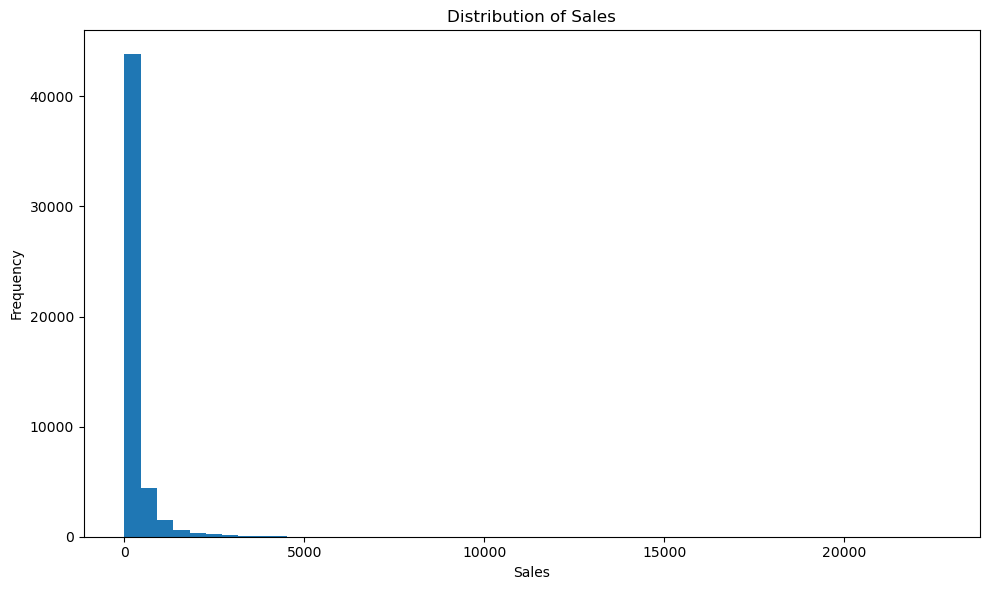

In [26]:
# ============================================
# STEP 4.2: SALES DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

plt.hist(
    sales_df["Sales"],
    bins=50
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "outputs/figures/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ============================================
# STEP 4.3: MONTHLY SALES AGGREGATION
# ============================================

monthly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

print("=" * 60)
print("MONTHLY SALES DATA")
print("=" * 60)

print("\nShape:")
print(monthly_sales.shape)

print("\nFirst 10 Months:")
display(monthly_sales.head(10))

print("\nLast 10 Months:")
display(monthly_sales.tail(10))

print("\nDate Range:")
print(
    monthly_sales["Order Date"].min(),
    "to",
    monthly_sales["Order Date"].max()
)

MONTHLY SALES DATA

Shape:
(48, 2)

First 10 Months:


,Order Date,Sales
0,2011-01-01,98898.48886
1,2011-02-01,91152.15698
2,2011-03-01,145729.36736
3,2011-04-01,116915.76418
4,2011-05-01,146747.83610
5,2011-06-01,215207.38022
6,2011-07-01,115510.41912
7,2011-08-01,207581.49122
8,2011-09-01,290214.45534
9,2011-10-01,199071.26404



Last 10 Months:


,Order Date,Sales
38,2014-03-01,263100.77262
39,2014-04-01,242771.86130
40,2014-05-01,288401.04614
41,2014-06-01,401814.06310
42,2014-07-01,258705.68048
43,2014-08-01,456619.94236
44,2014-09-01,481157.24370
45,2014-10-01,422766.62916
46,2014-11-01,555279.02700
47,2014-12-01,503143.69348



Date Range:
2011-01-01 00:00:00 to 2014-12-01 00:00:00


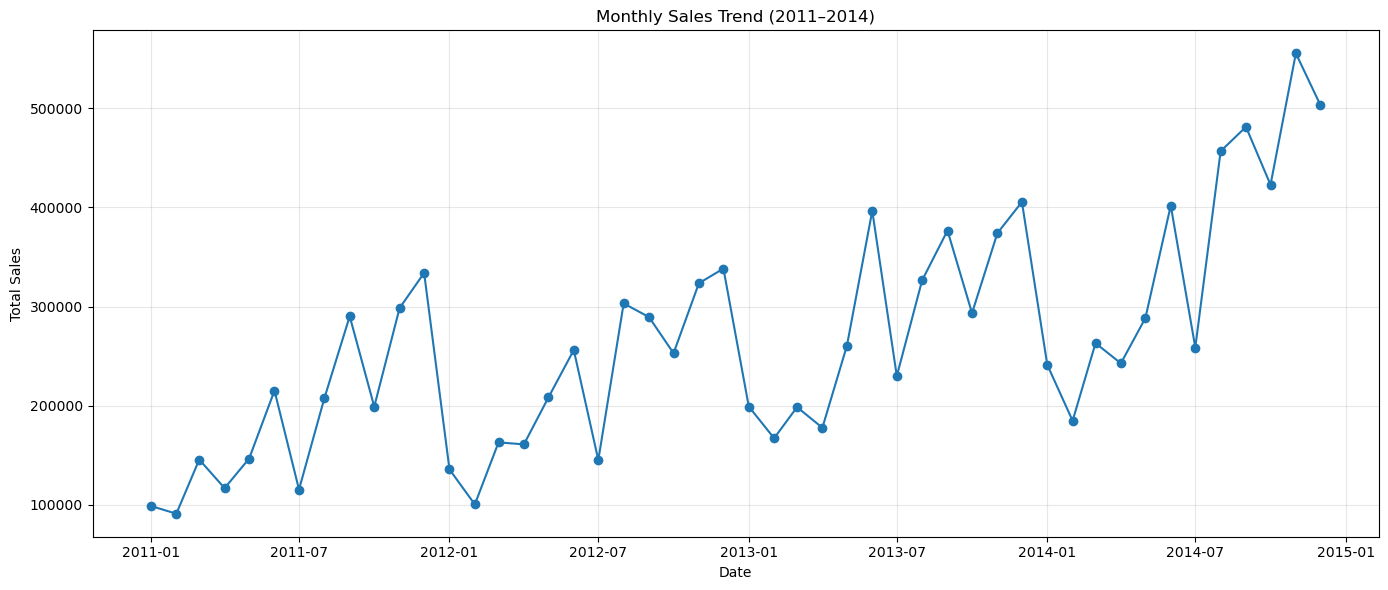

In [28]:
# ============================================
# STEP 4.4: MONTHLY SALES TREND
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend (2011–2014)")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/figures/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

YEARLY SALES


,Year,Sales
0,2011,2.259451e+06
1,2012,2.677439e+06
2,2013,3.405746e+06
3,2014,4.299866e+06


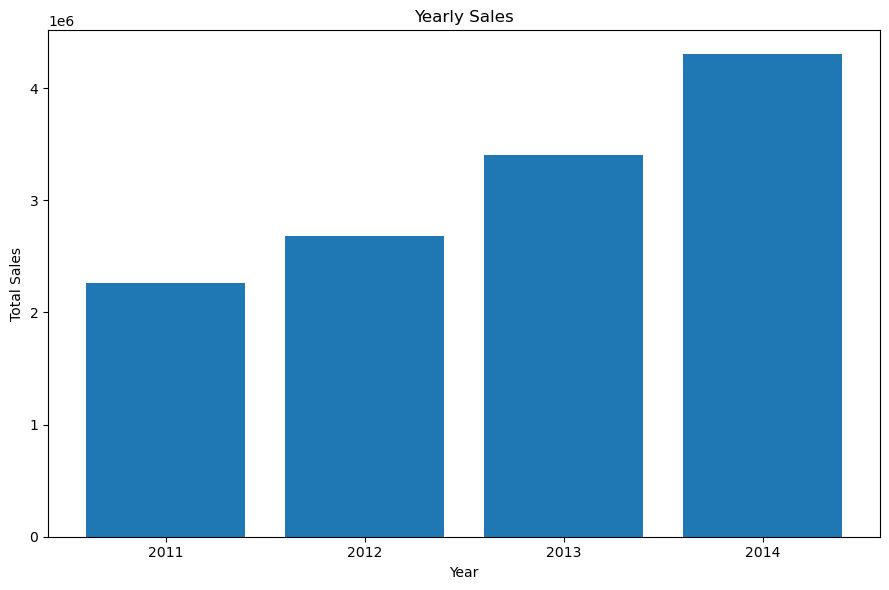

In [29]:
# ============================================
# STEP 4.5: YEARLY SALES
# ============================================

sales_df["Year"] = sales_df["Order Date"].dt.year

yearly_sales = (
    sales_df
    .groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

print("=" * 60)
print("YEARLY SALES")
print("=" * 60)

display(yearly_sales)

plt.figure(figsize=(9, 6))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "outputs/figures/yearly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

MONTHLY SEASONALITY


,Month,Sales,Month Name
0,1,259.766707,Jan
1,2,250.802297,Feb
2,3,253.871809,Mar
3,4,228.512009,Apr
4,5,241.262967,May
5,6,238.176093,Jun
6,7,236.696727,Jul
7,8,254.791880,Aug
8,9,240.565709,Sep
9,10,260.174696,Oct


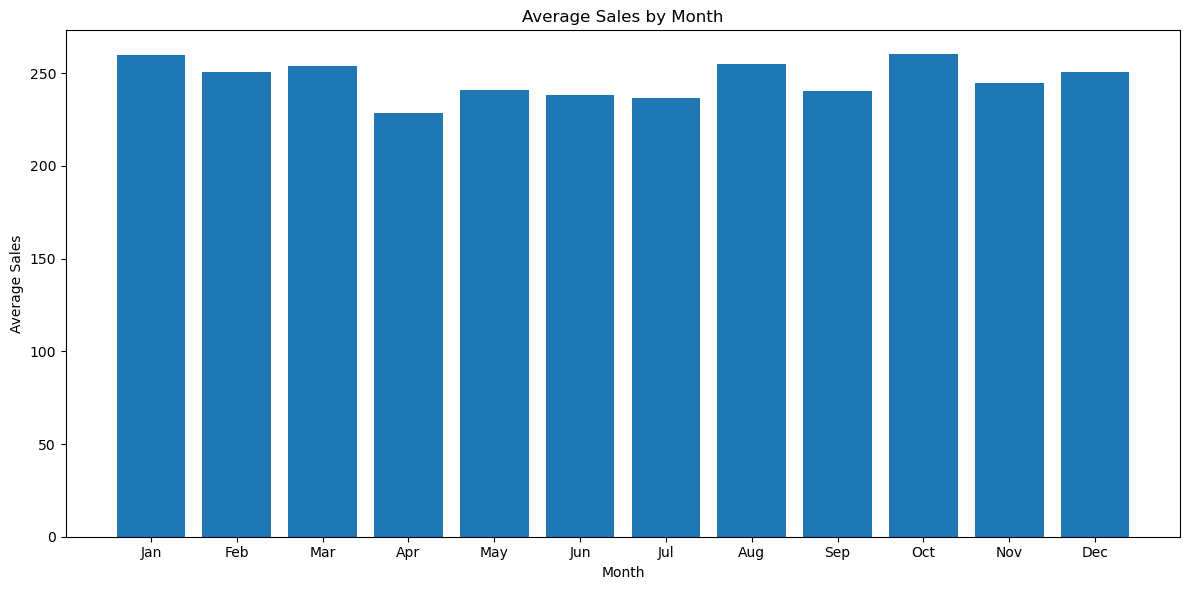

In [30]:
# ============================================
# STEP 4.6: MONTHLY SEASONALITY
# ============================================

sales_df["Month"] = sales_df["Order Date"].dt.month

monthly_seasonality = (
    sales_df
    .groupby("Month")["Sales"]
    .mean()
    .reset_index()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

monthly_seasonality["Month Name"] = (
    monthly_seasonality["Month"]
    .map(dict(enumerate(month_names, start=1)))
)

print("=" * 60)
print("MONTHLY SEASONALITY")
print("=" * 60)

display(monthly_seasonality)

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_seasonality["Month Name"],
    monthly_seasonality["Sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.tight_layout()

plt.savefig(
    "outputs/figures/monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SALES BY CATEGORY


Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64

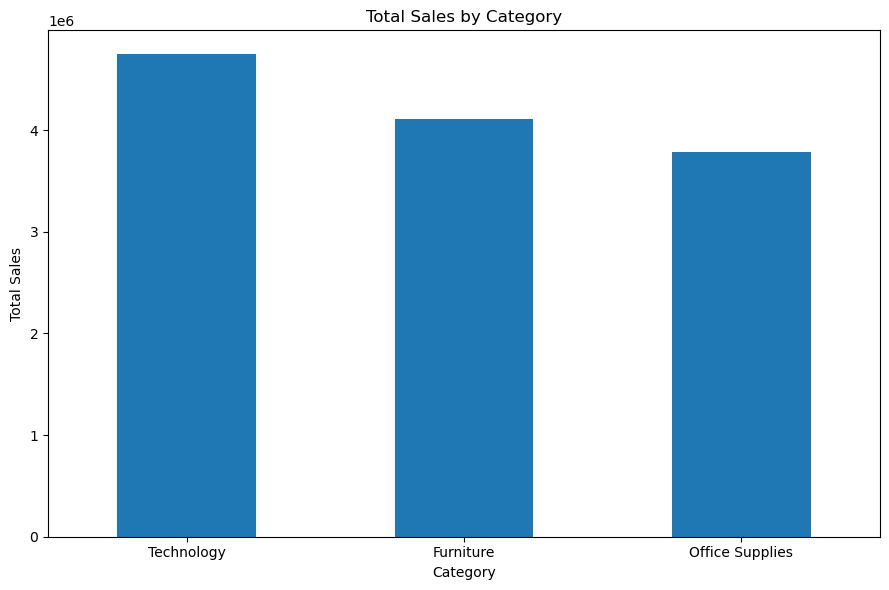

In [31]:
# ============================================
# STEP 4.7: CATEGORY SALES
# ============================================

category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("=" * 60)
print("SALES BY CATEGORY")
print("=" * 60)

display(category_sales)

plt.figure(figsize=(9, 6))

category_sales.plot(
    kind="bar"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "outputs/figures/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# ============================================================
# STEP 6: LAG & ROLLING FEATURES
# ============================================================

print("=" * 60)
print("STEP 6: LAG & ROLLING FEATURES")
print("=" * 60)


# ------------------------------------------------------------
# 1. Rebuild monthly sales dataset
# ------------------------------------------------------------

monthly_forecast = (
    sales_df
    .set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .reset_index()
)

# Rename columns
monthly_forecast.columns = ["Date", "Sales"]

# Sort chronologically
monthly_forecast = (
    monthly_forecast
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Create time-based features
# ------------------------------------------------------------

monthly_forecast["Year"] = monthly_forecast["Date"].dt.year
monthly_forecast["Month"] = monthly_forecast["Date"].dt.month
monthly_forecast["Quarter"] = monthly_forecast["Date"].dt.quarter


# ------------------------------------------------------------
# 3. Create lag features
# ------------------------------------------------------------

monthly_forecast["Lag_1"] = (
    monthly_forecast["Sales"].shift(1)
)

monthly_forecast["Lag_2"] = (
    monthly_forecast["Sales"].shift(2)
)

monthly_forecast["Lag_3"] = (
    monthly_forecast["Sales"].shift(3)
)

monthly_forecast["Lag_6"] = (
    monthly_forecast["Sales"].shift(6)
)

monthly_forecast["Lag_12"] = (
    monthly_forecast["Sales"].shift(12)
)


# ------------------------------------------------------------
# 4. Create rolling mean features
# ------------------------------------------------------------

# IMPORTANT:
# shift(1) ensures the current month's Sales
# is NOT included in its own rolling calculation.

monthly_forecast["Rolling_Mean_3"] = (
    monthly_forecast["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_forecast["Rolling_Mean_6"] = (
    monthly_forecast["Sales"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

monthly_forecast["Rolling_Mean_12"] = (
    monthly_forecast["Sales"]
    .shift(1)
    .rolling(window=12)
    .mean()
)


# ------------------------------------------------------------
# 5. Display lag and rolling features
# ------------------------------------------------------------

print("\nLag and Rolling Features Preview:")

display(
    monthly_forecast[
        [
            "Date",
            "Sales",
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Lag_6",
            "Lag_12",
            "Rolling_Mean_3",
            "Rolling_Mean_6",
            "Rolling_Mean_12"
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 6. Check missing values
# ------------------------------------------------------------

print("\nMissing Values Before Removing Initial Rows:")

display(
    monthly_forecast.isnull()
    .sum()
    .to_frame("Missing Values")
)


# ------------------------------------------------------------
# 7. Remove rows without sufficient historical data
# ------------------------------------------------------------

forecast_df = (
    monthly_forecast
    .dropna()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display final forecasting dataset
# ------------------------------------------------------------

print("\nFinal Forecasting Dataset Shape:")
print(forecast_df.shape)

print("\nForecasting Date Range:")
print(
    forecast_df["Date"].min(),
    "to",
    forecast_df["Date"].max()
)

print("\nFinal Forecasting Dataset Preview:")

display(forecast_df.head())


# ------------------------------------------------------------
# 9. Define model features and target
# ------------------------------------------------------------

feature_columns = [
    "Year",
    "Month",
    "Quarter",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6",
    "Rolling_Mean_12"
]

target_column = "Sales"


print("\nFeatures used for forecasting:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget variable:")
print("-", target_column)


# ------------------------------------------------------------
# 10. Final validation
# ------------------------------------------------------------

print("\nFinal Dataset Information:")

print("Number of observations:", len(forecast_df))
print("Number of features:", len(feature_columns))
print("Missing values:", forecast_df[feature_columns + [target_column]].isnull().sum().sum())


print("\n" + "=" * 60)
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 6: LAG & ROLLING FEATURES

Lag and Rolling Features Preview:


,Date,Sales,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
0,2011-01-01,98898.48886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-02-01,91152.15698,98898.48886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-03-01,145729.36736,91152.15698,98898.48886,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-04-01,116915.76418,145729.36736,91152.15698,98898.48886,NaN,NaN,111926.671067,NaN,NaN
4,2011-05-01,146747.83610,116915.76418,145729.36736,91152.15698,NaN,NaN,117932.429507,NaN,NaN
5,2011-06-01,215207.38022,146747.83610,116915.76418,145729.36736,NaN,NaN,136464.322547,NaN,NaN
6,2011-07-01,115510.41912,215207.38022,146747.83610,116915.76418,98898.48886,NaN,159623.660167,135775.165617,NaN
7,2011-08-01,207581.49122,115510.41912,215207.38022,146747.83610,91152.15698,NaN,159155.211813,138543.820660,NaN
8,2011-09-01,290214.45534,207581.49122,115510.41912,215207.38022,145729.36736,NaN,179433.096853,157948.709700,NaN
9,2011-10-01,199071.26404,290214.45534,207581.49122,115510.41912,116915.76418,NaN,204435.455227,182029.557697,NaN



Missing Values Before Removing Initial Rows:


,Missing Values
Date,0
Sales,0
Year,0
Month,0
Quarter,0
Lag_1,1
Lag_2,2
Lag_3,3
Lag_6,6
Lag_12,12



Final Forecasting Dataset Shape:
(36, 13)

Forecasting Date Range:
2012-01-01 00:00:00 to 2014-12-01 00:00:00

Final Forecasting Dataset Preview:


,Date,Sales,Year,Month,Quarter,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
0,2012-01-01,135780.72024,2012,1,1,333925.73460,298496.53752,199071.26404,115510.41912,98898.48886,277164.512053,240799.983640,188287.574628
1,2012-02-01,100510.21698,2012,2,1,135780.72024,333925.73460,298496.53752,207581.49122,91152.15698,256067.664120,244178.367160,191361.093910
2,2012-03-01,163076.77116,2012,3,1,100510.21698,135780.72024,333925.73460,290214.45534,145729.36736,190072.223940,226333.154787,192140.932243
3,2012-04-01,161052.26952,2012,4,2,163076.77116,100510.21698,135780.72024,199071.26404,116915.76418,133122.569460,205143.540757,193586.549227
4,2012-05-01,208364.89124,2012,5,2,161052.26952,163076.77116,100510.21698,298496.53752,146747.83610,141546.419220,198807.041670,197264.591338



Features used for forecasting:
- Year
- Month
- Quarter
- Lag_1
- Lag_2
- Lag_3
- Lag_6
- Lag_12
- Rolling_Mean_3
- Rolling_Mean_6
- Rolling_Mean_12

Target variable:
- Sales

Final Dataset Information:
Number of observations: 36
Number of features: 11
Missing values: 0

STEP 6 COMPLETED SUCCESSFULLY


STEP 7: CHRONOLOGICAL TRAIN / TEST SPLIT

Total observations: 36
Training observations: 28
Testing observations: 8

Training Period:
Start: 2012-01-01 00:00:00
End: 2014-04-01 00:00:00

Testing Period:
Start: 2014-05-01 00:00:00
End: 2014-12-01 00:00:00

Chronological Split Verification:
Last training date: 2014-04-01 00:00:00
First testing date: 2014-05-01 00:00:00
✓ No temporal overlap between training and testing data.

Dataset Shapes:
X_train: (28, 11)
X_test : (8, 11)
y_train: (28,)
y_test : (8,)

Training Data Preview:


,Date,Sales
0,2012-01-01,135780.72024
1,2012-02-01,100510.21698
2,2012-03-01,163076.77116
3,2012-04-01,161052.26952
4,2012-05-01,208364.89124



Testing Data Preview:


,Date,Sales
28,2014-05-01,288401.04614
29,2014-06-01,401814.06310
30,2014-07-01,258705.68048
31,2014-08-01,456619.94236
32,2014-09-01,481157.24370


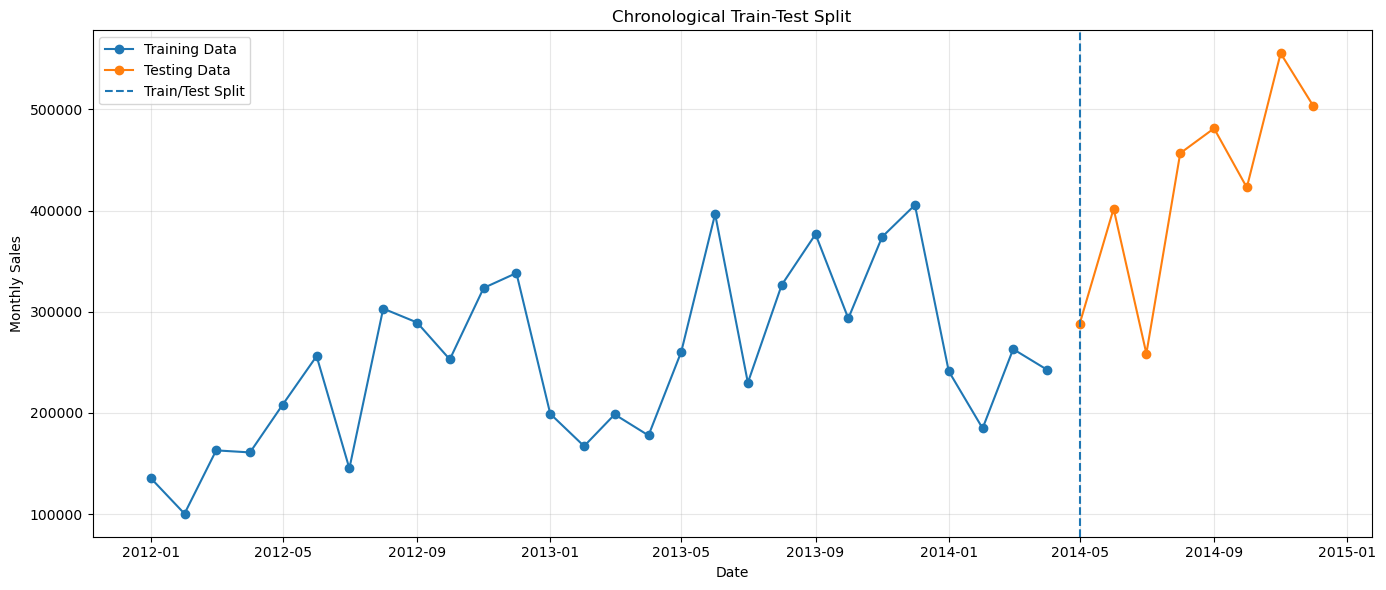


STEP 7 COMPLETED SUCCESSFULLY


In [34]:
# ============================================================
# STEP 7: CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

print("=" * 60)
print("STEP 7: CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 60)


# ------------------------------------------------------------
# 1. Define features and target
# ------------------------------------------------------------

X = forecast_df[feature_columns]
y = forecast_df[target_column]


# ------------------------------------------------------------
# 2. Calculate chronological split point
# ------------------------------------------------------------

split_index = int(len(forecast_df) * 0.80)

print("\nTotal observations:", len(forecast_df))
print("Training observations:", split_index)
print("Testing observations:", len(forecast_df) - split_index)


# ------------------------------------------------------------
# 3. Perform chronological split
# ------------------------------------------------------------

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()


# ------------------------------------------------------------
# 4. Get corresponding dates
# ------------------------------------------------------------

train_dates = forecast_df["Date"].iloc[:split_index].copy()
test_dates = forecast_df["Date"].iloc[split_index:].copy()


# ------------------------------------------------------------
# 5. Display training period
# ------------------------------------------------------------

print("\nTraining Period:")
print("Start:", train_dates.min())
print("End:", train_dates.max())


# ------------------------------------------------------------
# 6. Display testing period
# ------------------------------------------------------------

print("\nTesting Period:")
print("Start:", test_dates.min())
print("End:", test_dates.max())


# ------------------------------------------------------------
# 7. Verify chronological order
# ------------------------------------------------------------

print("\nChronological Split Verification:")

print(
    "Last training date:",
    train_dates.max()
)

print(
    "First testing date:",
    test_dates.min()
)

if train_dates.max() < test_dates.min():
    print("✓ No temporal overlap between training and testing data.")
else:
    print("✗ WARNING: Temporal overlap detected.")


# ------------------------------------------------------------
# 8. Display shapes
# ------------------------------------------------------------

print("\nDataset Shapes:")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# 9. Display training data preview
# ------------------------------------------------------------

print("\nTraining Data Preview:")

display(
    pd.DataFrame({
        "Date": train_dates,
        "Sales": y_train
    }).head()
)


# ------------------------------------------------------------
# 10. Display testing data preview
# ------------------------------------------------------------

print("\nTesting Data Preview:")

display(
    pd.DataFrame({
        "Date": test_dates,
        "Sales": y_test
    }).head()
)


# ------------------------------------------------------------
# 11. Visualize train/test split
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    train_dates,
    y_train,
    marker="o",
    label="Training Data"
)

plt.plot(
    test_dates,
    y_test,
    marker="o",
    label="Testing Data"
)

plt.axvline(
    x=test_dates.iloc[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 8: LINEAR REGRESSION MODEL

Linear Regression model trained successfully.

Linear Regression Predictions:


,Date,Actual Sales,Predicted Sales,Error,Absolute Error
0,2014-05-01,288401.05,326558.53,-38157.48,38157.48
1,2014-06-01,401814.06,447508.27,-45694.20,45694.20
2,2014-07-01,258705.68,316371.30,-57665.62,57665.62
3,2014-08-01,456619.94,403802.00,52817.94,52817.94
4,2014-09-01,481157.24,441549.02,39608.22,39608.22
5,2014-10-01,422766.63,357828.24,64938.39,64938.39
6,2014-11-01,555279.03,389268.04,166010.98,166010.98
7,2014-12-01,503143.69,415492.56,87651.14,87651.14



Linear Regression Evaluation Metrics:
---------------------------------------------
MAE  : 69,068.00
RMSE : 79,598.36
R²   : 0.3147


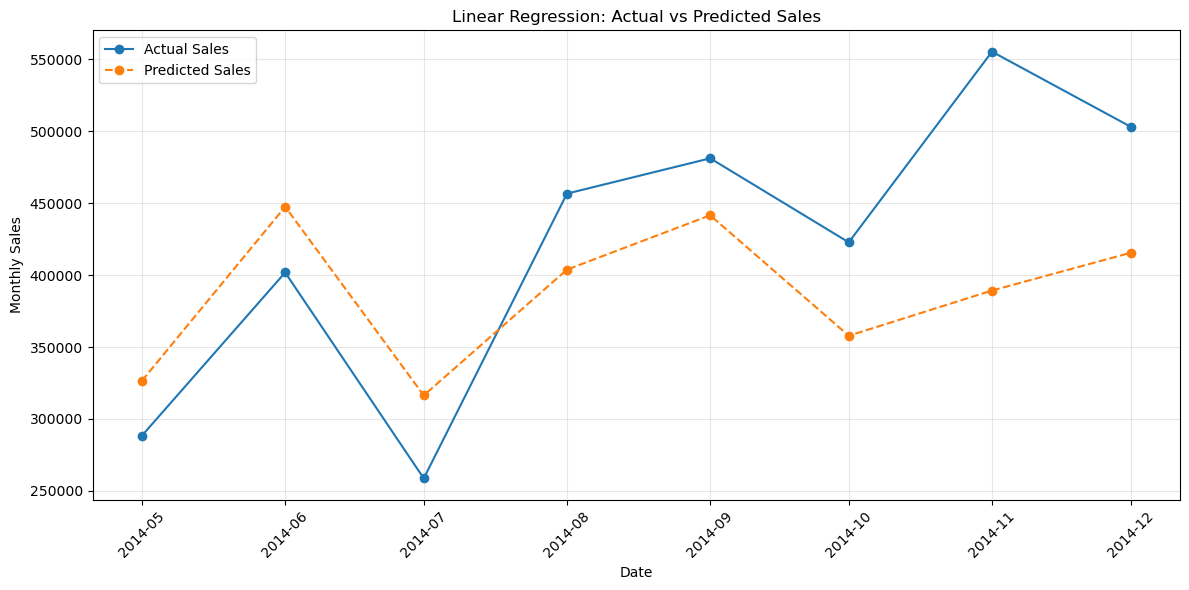


STEP 8 COMPLETED SUCCESSFULLY


In [35]:
# ============================================================
# STEP 8: LINEAR REGRESSION MODEL
# ============================================================

print("=" * 60)
print("STEP 8: LINEAR REGRESSION MODEL")
print("=" * 60)


# ------------------------------------------------------------
# 1. Import Linear Regression
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression


# ------------------------------------------------------------
# 2. Create Linear Regression model
# ------------------------------------------------------------

linear_model = LinearRegression()


# ------------------------------------------------------------
# 3. Train the model
# ------------------------------------------------------------

linear_model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")


# ------------------------------------------------------------
# 4. Generate predictions
# ------------------------------------------------------------

y_pred_lr = linear_model.predict(X_test)


# ------------------------------------------------------------
# 5. Create prediction comparison table
# ------------------------------------------------------------

linear_results = pd.DataFrame({
    "Date": test_dates.values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_lr
})

linear_results["Error"] = (
    linear_results["Actual Sales"]
    - linear_results["Predicted Sales"]
)

linear_results["Absolute Error"] = (
    linear_results["Error"].abs()
)


# ------------------------------------------------------------
# 6. Display predictions
# ------------------------------------------------------------

print("\nLinear Regression Predictions:")

display(
    linear_results.round(2)
)


# ------------------------------------------------------------
# 7. Calculate evaluation metrics
# ------------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = mean_squared_error(
    y_test,
    y_pred_lr
) ** 0.5

r2_lr = r2_score(
    y_test,
    y_pred_lr
)


# ------------------------------------------------------------
# 8. Display metrics
# ------------------------------------------------------------

print("\nLinear Regression Evaluation Metrics:")
print("-" * 45)

print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")


# ------------------------------------------------------------
# 9. Visualize actual vs predicted sales
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_dates,
    y_pred_lr,
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Linear Regression: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 9: RANDOM FOREST REGRESSION MODEL

Random Forest model trained successfully.

Random Forest Predictions:


,Date,Actual Sales,Predicted Sales,Error,Absolute Error
0,2014-05-01,288401.05,355405.01,-67003.97,67003.97
1,2014-06-01,401814.06,364442.38,37371.69,37371.69
2,2014-07-01,258705.68,280753.39,-22047.71,22047.71
3,2014-08-01,456619.94,348560.65,108059.30,108059.30
4,2014-09-01,481157.24,372557.12,108600.13,108600.13
5,2014-10-01,422766.63,354887.39,67879.24,67879.24
6,2014-11-01,555279.03,375015.47,180263.55,180263.55
7,2014-12-01,503143.69,386915.16,116228.53,116228.53



Random Forest Evaluation Metrics:
---------------------------------------------
MAE  : 88,431.76
RMSE : 100,283.78
R²   : -0.0878


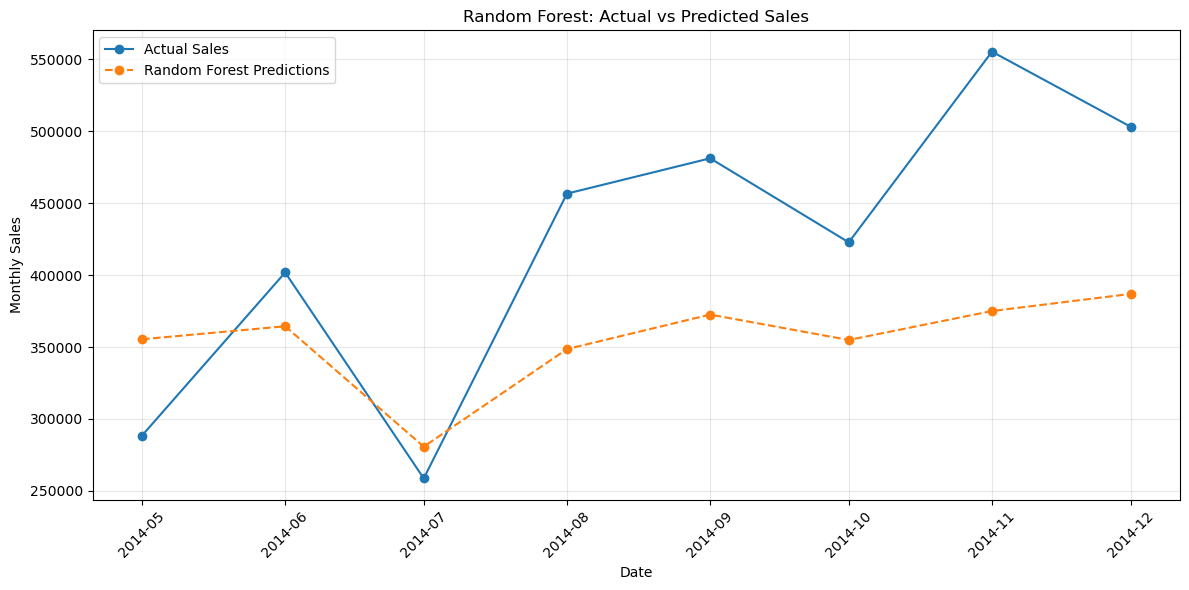


Random Forest Feature Importance:


,Feature,Importance
0,Lag_12,0.8122
1,Month,0.0529
2,Lag_6,0.0347
3,Rolling_Mean_12,0.0338
4,Rolling_Mean_3,0.0163
5,Lag_1,0.0129
6,Lag_3,0.0123
7,Quarter,0.0067
8,Rolling_Mean_6,0.0066
9,Lag_2,0.0064


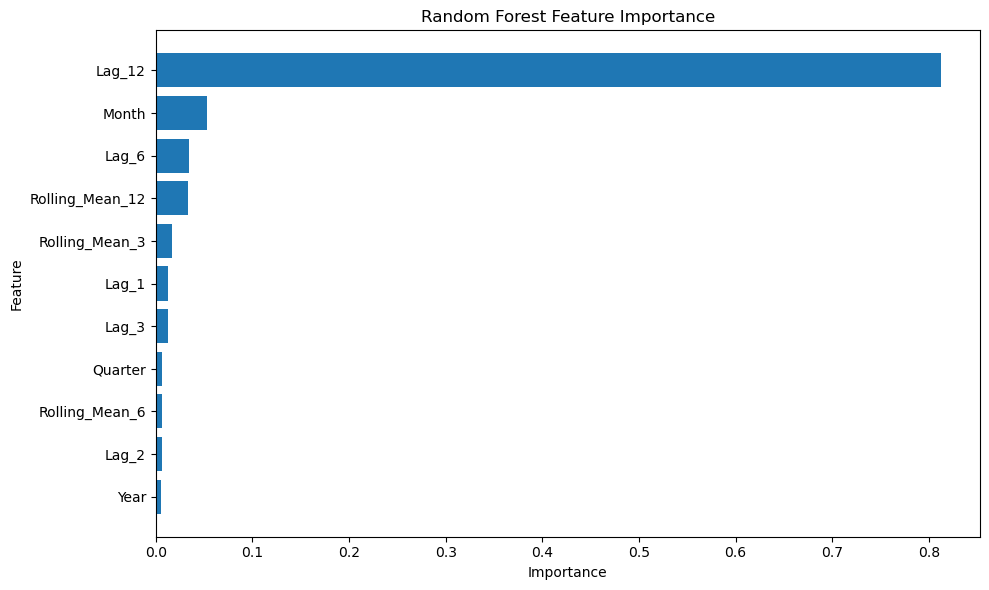


STEP 9 COMPLETED SUCCESSFULLY


In [36]:
# ============================================================
# STEP 9: RANDOM FOREST REGRESSION MODEL
# ============================================================

print("=" * 60)
print("STEP 9: RANDOM FOREST REGRESSION MODEL")
print("=" * 60)


# ------------------------------------------------------------
# 1. Import Random Forest
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor


# ------------------------------------------------------------
# 2. Create Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Train the model
# ------------------------------------------------------------

rf_model.fit(X_train, y_train)

print("\nRandom Forest model trained successfully.")


# ------------------------------------------------------------
# 4. Generate predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)


# ------------------------------------------------------------
# 5. Create prediction comparison table
# ------------------------------------------------------------

rf_results = pd.DataFrame({
    "Date": test_dates.values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

rf_results["Error"] = (
    rf_results["Actual Sales"]
    - rf_results["Predicted Sales"]
)

rf_results["Absolute Error"] = (
    rf_results["Error"].abs()
)


# ------------------------------------------------------------
# 6. Display predictions
# ------------------------------------------------------------

print("\nRandom Forest Predictions:")

display(
    rf_results.round(2)
)


# ------------------------------------------------------------
# 7. Calculate evaluation metrics
# ------------------------------------------------------------

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)


# ------------------------------------------------------------
# 8. Display metrics
# ------------------------------------------------------------

print("\nRandom Forest Evaluation Metrics:")
print("-" * 45)

print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")


# ------------------------------------------------------------
# 9. Visualize actual vs predicted sales
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    y_test,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_dates,
    y_pred_rf,
    marker="o",
    linestyle="--",
    label="Random Forest Predictions"
)

plt.title("Random Forest: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Feature Importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nRandom Forest Feature Importance:")

display(
    feature_importance.round(4)
)


# ------------------------------------------------------------
# 11. Feature importance visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 10: MODEL COMPARISON

Model Performance Comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,69067.9970,79598.3562,0.3147
1,Random Forest,88431.7643,100283.7761,-0.0878



Metric Comparison:
---------------------------------------------
Lower MAE  : Linear Regression
Lower RMSE : Linear Regression
Higher R²  : Linear Regression


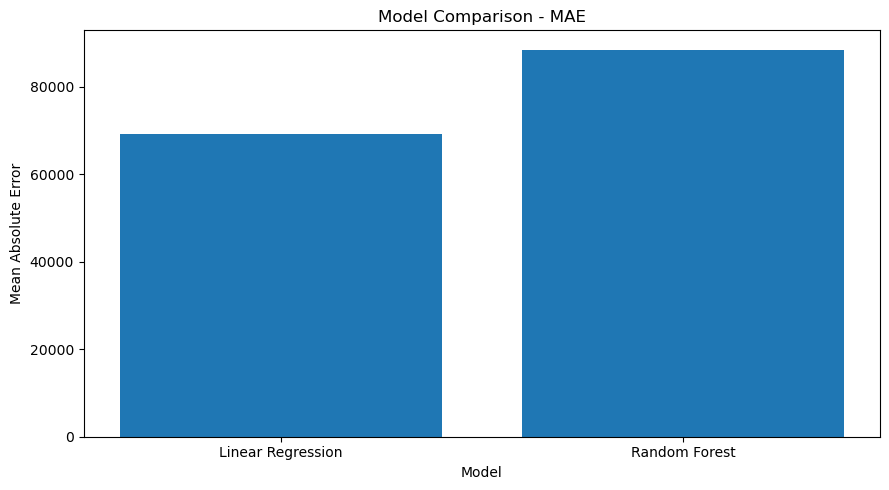

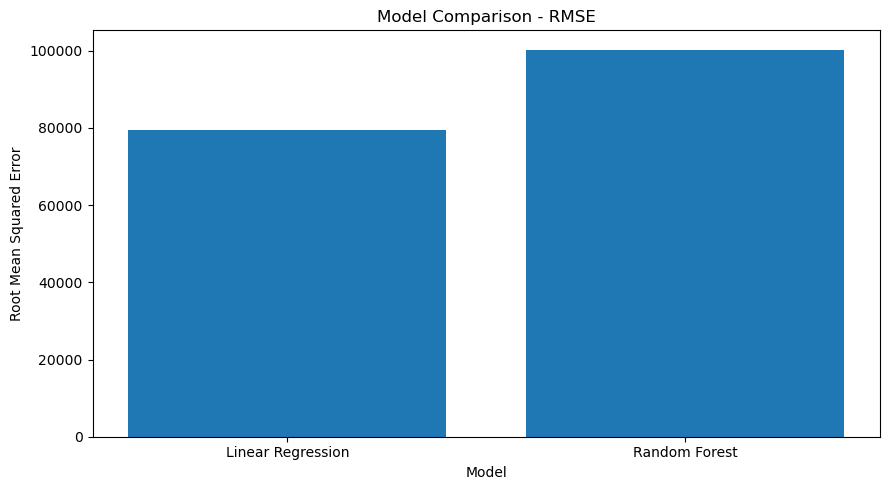

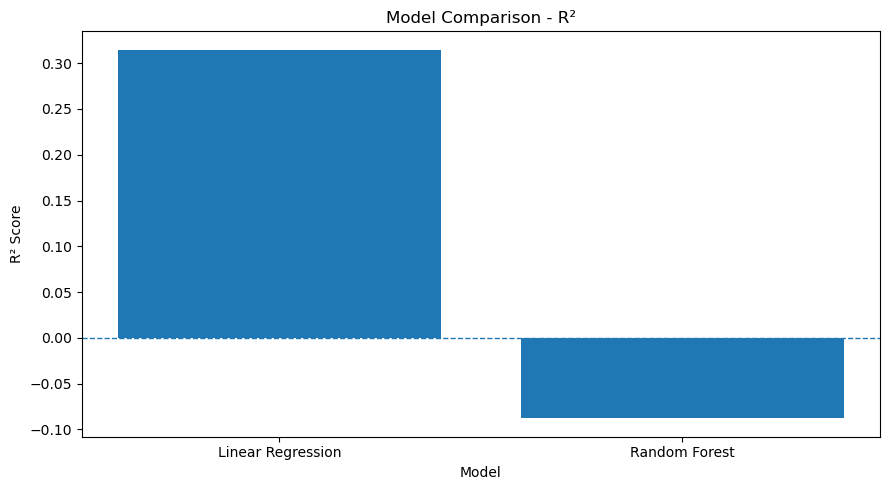


MODEL COMPARISON SUMMARY
Linear Regression → MAE: 69,068.00, RMSE: 79,598.36, R²: 0.3147
Random Forest     → MAE: 88,431.76, RMSE: 100,283.78, R²: -0.0878

STEP 10 COMPLETED SUCCESSFULLY


In [37]:
# ============================================================
# STEP 10: MODEL COMPARISON
# ============================================================

print("=" * 60)
print("STEP 10: MODEL COMPARISON")
print("=" * 60)


# ------------------------------------------------------------
# 1. Create model comparison dataframe
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})


# ------------------------------------------------------------
# 2. Display comparison
# ------------------------------------------------------------

print("\nModel Performance Comparison:")

display(
    model_comparison.round(4)
)


# ------------------------------------------------------------
# 3. Identify the model with lower MAE
# ------------------------------------------------------------

best_mae_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]


# ------------------------------------------------------------
# 4. Identify the model with lower RMSE
# ------------------------------------------------------------

best_rmse_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]


# ------------------------------------------------------------
# 5. Identify the model with higher R²
# ------------------------------------------------------------

best_r2_model = model_comparison.loc[
    model_comparison["R2"].idxmax(),
    "Model"
]


# ------------------------------------------------------------
# 6. Print metric-based comparison
# ------------------------------------------------------------

print("\nMetric Comparison:")
print("-" * 45)

print(
    f"Lower MAE  : {best_mae_model}"
)

print(
    f"Lower RMSE : {best_rmse_model}"
)

print(
    f"Higher R²  : {best_r2_model}"
)


# ------------------------------------------------------------
# 7. Visualize MAE comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Visualize RMSE comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Visualize R² comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Final comparison summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print(
    f"Linear Regression → "
    f"MAE: {mae_lr:,.2f}, "
    f"RMSE: {rmse_lr:,.2f}, "
    f"R²: {r2_lr:.4f}"
)

print(
    f"Random Forest     → "
    f"MAE: {mae_rf:,.2f}, "
    f"RMSE: {rmse_rf:,.2f}, "
    f"R²: {r2_rf:.4f}"
)

print("\n" + "=" * 60)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("=" * 60)

he two regression models were evaluated using MAE, RMSE, and R² on a chronological hold-out test set. Linear Regression achieved MAE of 69,068.00, RMSE of 79,598.36, and R² of 0.3147, while Random Forest achieved MAE of 88,431.76, RMSE of 100,283.78, and R² of -0.0878. Based on these test-set metrics, Linear Regression showed lower prediction errors and a higher R² for this dataset and evaluation period.

STEP 11: FUTURE SALES FORECASTING

Forecasting Model:
Linear Regression

Future Sales Forecast:


,Date,Forecasted Sales,Year,Month,Quarter,Month Name
0,2015-01-01,238103.84,2015,1,1,January
1,2015-02-01,178025.47,2015,2,1,February
2,2015-03-01,269086.65,2015,3,1,March
3,2015-04-01,272591.10,2015,4,2,April
4,2015-05-01,348741.56,2015,5,2,May
5,2015-06-01,457920.93,2015,6,2,June



Forecast Summary:
---------------------------------------------
Forecast Period       : January 2015 to June 2015
Total Forecast Sales  : 1,764,469.54
Average Monthly Sales : 294,078.26
Highest Forecast     : June 2015 → 457,920.93
Lowest Forecast      : February 2015 → 178,025.47

Change from December 2014 to January 2015: -52.68%


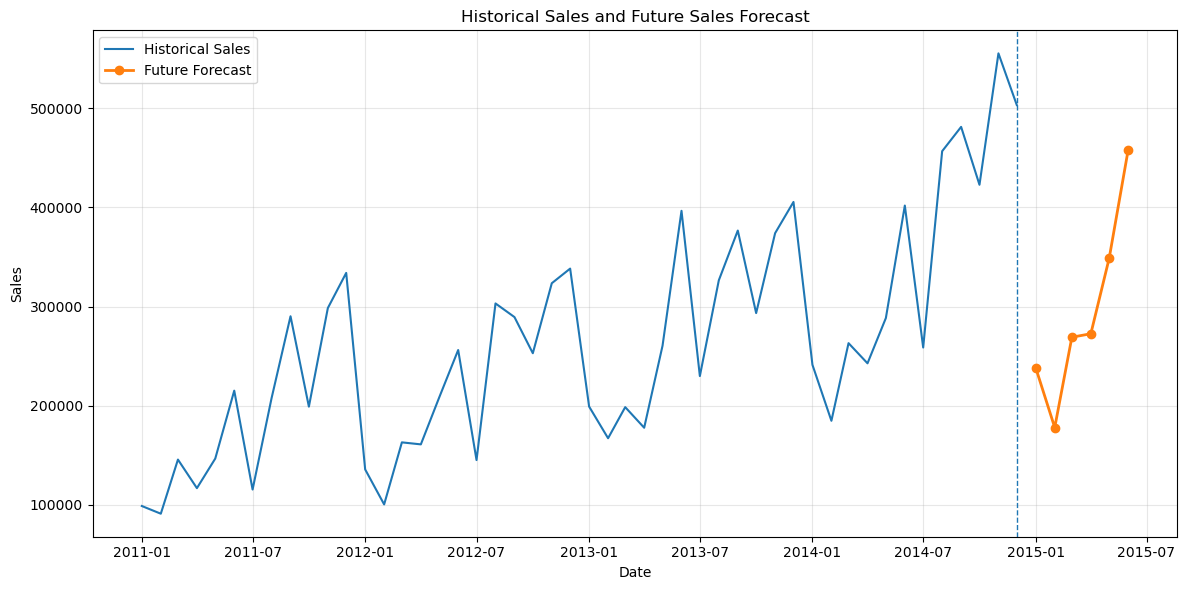


STEP 11 COMPLETED SUCCESSFULLY


In [38]:
# ============================================================
# STEP 11: FUTURE SALES FORECASTING
# ============================================================

print("=" * 60)
print("STEP 11: FUTURE SALES FORECASTING")
print("=" * 60)


# ------------------------------------------------------------
# 1. Select model for future forecasting
# ------------------------------------------------------------

forecast_model = linear_model

print("\nForecasting Model:")
print("Linear Regression")


# ------------------------------------------------------------
# 2. Prepare historical monthly sales
# ------------------------------------------------------------

historical_sales = (
    sales_df
    .set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .sort_index()
)


# ------------------------------------------------------------
# 3. Create a copy for recursive forecasting
# ------------------------------------------------------------

forecast_series = historical_sales.copy()


# ------------------------------------------------------------
# 4. Define forecast horizon
# ------------------------------------------------------------

forecast_horizon = 6

last_historical_date = forecast_series.index.max()

future_dates = pd.date_range(
    start=last_historical_date + pd.DateOffset(months=1),
    periods=forecast_horizon,
    freq="MS"
)


# ------------------------------------------------------------
# 5. Recursive forecasting
# ------------------------------------------------------------

future_predictions = []


for future_date in future_dates:

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------

    year = future_date.year
    month = future_date.month
    quarter = future_date.quarter


    # --------------------------------------------------------
    # Lag features
    # --------------------------------------------------------

    lag_1 = forecast_series.iloc[-1]
    lag_2 = forecast_series.iloc[-2]
    lag_3 = forecast_series.iloc[-3]
    lag_6 = forecast_series.iloc[-6]
    lag_12 = forecast_series.iloc[-12]


    # --------------------------------------------------------
    # Rolling mean features
    # Use only values available BEFORE the forecast month
    # --------------------------------------------------------

    rolling_mean_3 = forecast_series.iloc[-3:].mean()
    rolling_mean_6 = forecast_series.iloc[-6:].mean()
    rolling_mean_12 = forecast_series.iloc[-12:].mean()


    # --------------------------------------------------------
    # Create feature row
    # --------------------------------------------------------

    future_features = pd.DataFrame({
        "Year": [year],
        "Month": [month],
        "Quarter": [quarter],
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Lag_6": [lag_6],
        "Lag_12": [lag_12],
        "Rolling_Mean_3": [rolling_mean_3],
        "Rolling_Mean_6": [rolling_mean_6],
        "Rolling_Mean_12": [rolling_mean_12]
    })


    # --------------------------------------------------------
    # Predict future sales
    # --------------------------------------------------------

    prediction = forecast_model.predict(
        future_features[feature_columns]
    )[0]


    # --------------------------------------------------------
    # Prevent impossible negative sales
    # --------------------------------------------------------

    prediction = max(0, prediction)


    # --------------------------------------------------------
    # Store prediction
    # --------------------------------------------------------

    future_predictions.append(prediction)


    # --------------------------------------------------------
    # Add prediction to series
    # This allows recursive forecasting
    # --------------------------------------------------------

    forecast_series.loc[future_date] = prediction


# ------------------------------------------------------------
# 6. Create forecast dataframe
# ------------------------------------------------------------

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Sales": future_predictions
})


future_forecast["Year"] = future_forecast["Date"].dt.year
future_forecast["Month"] = future_forecast["Date"].dt.month
future_forecast["Quarter"] = future_forecast["Date"].dt.quarter
future_forecast["Month Name"] = (
    future_forecast["Date"].dt.month_name()
)


# ------------------------------------------------------------
# 7. Display forecast
# ------------------------------------------------------------

print("\nFuture Sales Forecast:")

display(
    future_forecast.round(2)
)


# ------------------------------------------------------------
# 8. Forecast summary
# ------------------------------------------------------------

total_forecast_sales = (
    future_forecast["Forecasted Sales"].sum()
)

average_forecast_sales = (
    future_forecast["Forecasted Sales"].mean()
)

maximum_forecast = (
    future_forecast.loc[
        future_forecast["Forecasted Sales"].idxmax()
    ]
)

minimum_forecast = (
    future_forecast.loc[
        future_forecast["Forecasted Sales"].idxmin()
    ]
)


print("\nForecast Summary:")
print("-" * 45)

print(
    f"Forecast Period       : "
    f"{future_forecast['Date'].min().strftime('%B %Y')} "
    f"to "
    f"{future_forecast['Date'].max().strftime('%B %Y')}"
)

print(
    f"Total Forecast Sales  : "
    f"{total_forecast_sales:,.2f}"
)

print(
    f"Average Monthly Sales : "
    f"{average_forecast_sales:,.2f}"
)

print(
    f"Highest Forecast     : "
    f"{maximum_forecast['Month Name']} "
    f"{maximum_forecast['Year']} → "
    f"{maximum_forecast['Forecasted Sales']:,.2f}"
)

print(
    f"Lowest Forecast      : "
    f"{minimum_forecast['Month Name']} "
    f"{minimum_forecast['Year']} → "
    f"{minimum_forecast['Forecasted Sales']:,.2f}"
)


# ------------------------------------------------------------
# 9. Calculate forecast growth
# ------------------------------------------------------------

last_actual_sales = historical_sales.iloc[-1]

first_forecast_sales = future_forecast[
    "Forecasted Sales"
].iloc[0]


growth_percentage = (
    (first_forecast_sales - last_actual_sales)
    / last_actual_sales
) * 100


print(
    f"\nChange from December 2014 "
    f"to January 2015: {growth_percentage:.2f}%"
)


# ------------------------------------------------------------
# 10. Plot future forecast
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    historical_sales.index,
    historical_sales.values,
    label="Historical Sales"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linewidth=2,
    label="Future Forecast"
)

plt.axvline(
    x=last_historical_date,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Historical Sales and Future Sales Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 11 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 12: FINAL FORECAST VISUALIZATION


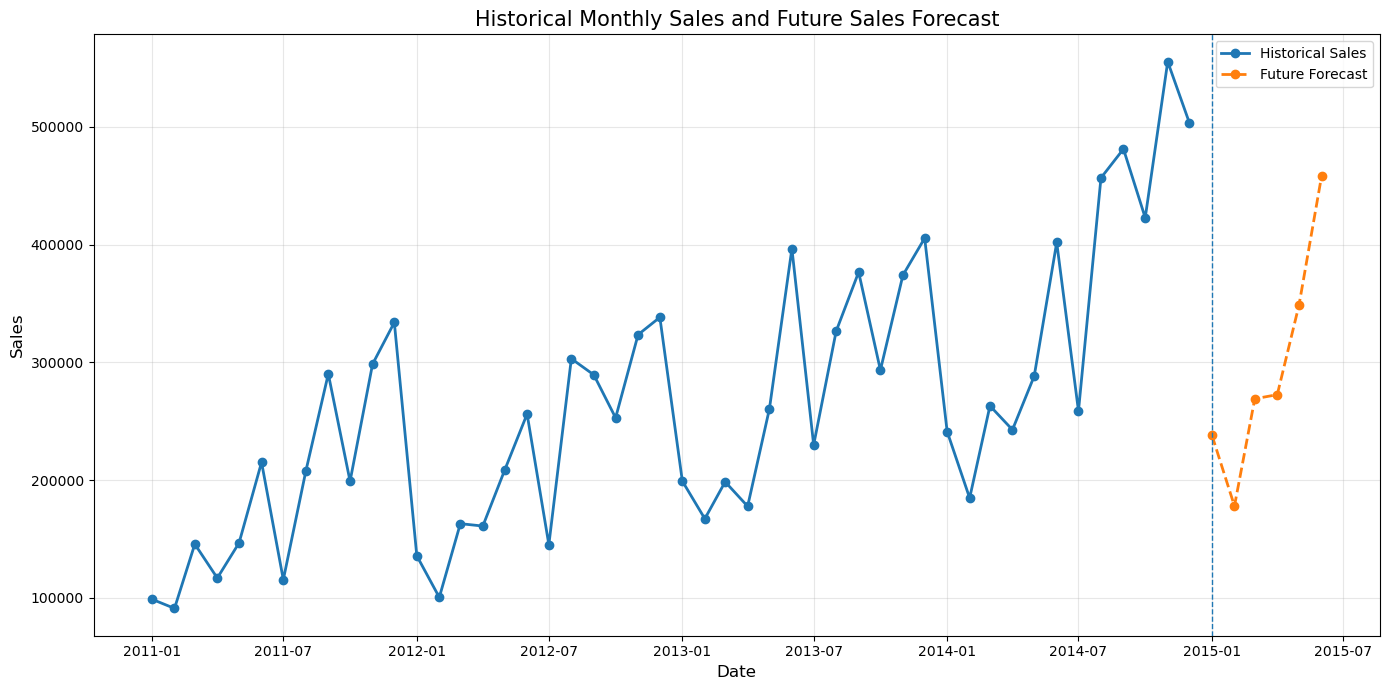

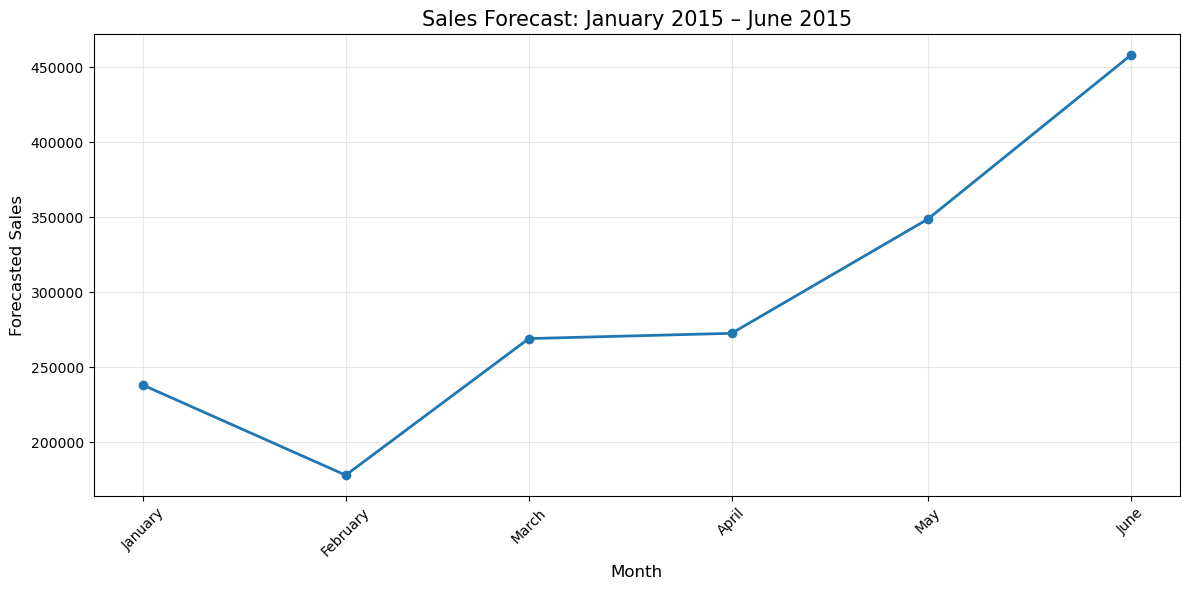


Forecast Trend:
---------------------------------------------
January 2015: 238,103.84
February 2015: 178,025.47
March 2015: 269,086.65
April 2015: 272,591.10
May 2015: 348,741.56
June 2015: 457,920.93

STEP 12 COMPLETED SUCCESSFULLY


In [39]:
# ============================================================
# STEP 12: FINAL FORECAST VISUALIZATION
# ============================================================

print("=" * 60)
print("STEP 12: FINAL FORECAST VISUALIZATION")
print("=" * 60)


# ------------------------------------------------------------
# 1. Prepare historical monthly sales
# ------------------------------------------------------------

historical_monthly = (
    sales_df
    .set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
    .reset_index()
)

historical_monthly.columns = ["Date", "Sales"]


# ------------------------------------------------------------
# 2. Create final forecast visualization
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))


# Historical sales
plt.plot(
    historical_monthly["Date"],
    historical_monthly["Sales"],
    marker="o",
    linewidth=2,
    label="Historical Sales"
)


# Future forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Future Forecast"
)


# Forecast starting point
forecast_start = future_forecast["Date"].iloc[0]

plt.axvline(
    x=forecast_start,
    linestyle="--",
    linewidth=1
)


# ------------------------------------------------------------
# 3. Add labels
# ------------------------------------------------------------

plt.title(
    "Historical Monthly Sales and Future Sales Forecast",
    fontsize=15
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Sales",
    fontsize=12
)


# ------------------------------------------------------------
# 4. Add grid and legend
# ------------------------------------------------------------

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 5. Forecast-only visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Sales Forecast: January 2015 – June 2015",
    fontsize=15
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Forecasted Sales",
    fontsize=12
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    future_forecast["Date"],
    future_forecast["Month Name"],
    rotation=45
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 6. Print forecast trend
# ------------------------------------------------------------

print("\nForecast Trend:")
print("-" * 45)

for _, row in future_forecast.iterrows():

    print(
        f"{row['Month Name']} {int(row['Year'])}: "
        f"{row['Forecasted Sales']:,.2f}"
    )


print("\n" + "=" * 60)
print("STEP 12 COMPLETED SUCCESSFULLY")
print("=" * 60)

In [40]:
# ============================================================
# STEP 13: BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================================

print("=" * 60)
print("STEP 13: BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)


# ============================================================
# 1. YEARLY SALES ANALYSIS
# ============================================================

yearly_sales = (
    sales_df
    .set_index("Order Date")["Sales"]
    .resample("YS")
    .sum()
    .reset_index()
)

yearly_sales.columns = ["Year", "Sales"]

yearly_sales["Year"] = yearly_sales["Year"].dt.year


# Calculate year-over-year growth
yearly_sales["YoY Growth (%)"] = (
    yearly_sales["Sales"].pct_change() * 100
)


print("\nYEARLY SALES PERFORMANCE")
print("-" * 50)

display(
    yearly_sales.round(2)
)


# ============================================================
# 2. MONTHLY SEASONALITY ANALYSIS
# ============================================================

monthly_seasonality = (
    historical_monthly
    .assign(
        Month=historical_monthly["Date"].dt.month,
        Month_Name=historical_monthly["Date"].dt.month_name()
    )
    .groupby(
        ["Month", "Month_Name"],
        as_index=False
    )["Sales"]
    .mean()
    .sort_values("Month")
)


print("\nMONTHLY SEASONALITY")
print("-" * 50)

display(
    monthly_seasonality.round(2)
)


# ============================================================
# 3. HIGHEST AND LOWEST HISTORICAL MONTH
# ============================================================

highest_historical_month = historical_monthly.loc[
    historical_monthly["Sales"].idxmax()
]

lowest_historical_month = historical_monthly.loc[
    historical_monthly["Sales"].idxmin()
]


print("\nHISTORICAL SALES EXTREMES")
print("-" * 50)

print(
    f"Highest historical month: "
    f"{highest_historical_month['Date'].strftime('%B %Y')} → "
    f"{highest_historical_month['Sales']:,.2f}"
)

print(
    f"Lowest historical month: "
    f"{lowest_historical_month['Date'].strftime('%B %Y')} → "
    f"{lowest_historical_month['Sales']:,.2f}"
)


# ============================================================
# 4. CATEGORY SALES ANALYSIS
# ============================================================

category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales.columns = ["Category", "Total Sales"]

category_sales["Sales Share (%)"] = (
    category_sales["Total Sales"]
    / category_sales["Total Sales"].sum()
    * 100
)


print("\nCATEGORY SALES CONTRIBUTION")
print("-" * 50)

display(
    category_sales.round(2)
)


# ============================================================
# 5. TOP SUB-CATEGORIES
# ============================================================

subcategory_sales = (
    sales_df
    .groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

subcategory_sales.columns = [
    "Sub-Category",
    "Total Sales"
]


print("\nTOP 10 SUB-CATEGORIES BY SALES")
print("-" * 50)

display(
    subcategory_sales.head(10).round(2)
)


# ============================================================
# 6. FORECAST ANALYSIS
# ============================================================

future_forecast["Month-over-Month Growth (%)"] = (
    future_forecast["Forecasted Sales"]
    .pct_change()
    * 100
)


print("\nFUTURE SALES FORECAST ANALYSIS")
print("-" * 50)

display(
    future_forecast[
        [
            "Date",
            "Month Name",
            "Forecasted Sales",
            "Month-over-Month Growth (%)"
        ]
    ].round(2)
)


# ============================================================
# 7. HISTORICAL VS FORECAST AVERAGE
# ============================================================

historical_average_monthly = (
    historical_monthly["Sales"].mean()
)

forecast_average_monthly = (
    future_forecast["Forecasted Sales"].mean()
)

average_change_percentage = (
    (forecast_average_monthly - historical_average_monthly)
    / historical_average_monthly
    * 100
)


print("\nHISTORICAL VS FORECAST COMPARISON")
print("-" * 50)

print(
    f"Historical average monthly sales: "
    f"{historical_average_monthly:,.2f}"
)

print(
    f"Forecast average monthly sales: "
    f"{forecast_average_monthly:,.2f}"
)

print(
    f"Difference: "
    f"{average_change_percentage:.2f}%"
)


# ============================================================
# 8. FORECAST HIGHEST / LOWEST MONTH
# ============================================================

forecast_highest = future_forecast.loc[
    future_forecast["Forecasted Sales"].idxmax()
]

forecast_lowest = future_forecast.loc[
    future_forecast["Forecasted Sales"].idxmin()
]


print("\nFORECAST EXTREMES")
print("-" * 50)

print(
    f"Highest forecast: "
    f"{forecast_highest['Month Name']} "
    f"{int(forecast_highest['Year'])} → "
    f"{forecast_highest['Forecasted Sales']:,.2f}"
)

print(
    f"Lowest forecast: "
    f"{forecast_lowest['Month Name']} "
    f"{int(forecast_lowest['Year'])} → "
    f"{forecast_lowest['Forecasted Sales']:,.2f}"
)


# ============================================================
# 9. BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("KEY BUSINESS INSIGHTS")
print("=" * 60)


# Yearly growth
for i in range(1, len(yearly_sales)):

    year = int(yearly_sales.loc[i, "Year"])
    growth = yearly_sales.loc[i, "YoY Growth (%)"]

    print(
        f"{year}: Year-over-year sales growth = "
        f"{growth:.2f}%"
    )


print(
    f"\nHighest historical sales month: "
    f"{highest_historical_month['Date'].strftime('%B %Y')} "
    f"({highest_historical_month['Sales']:,.2f})"
)

print(
    f"Lowest historical sales month: "
    f"{lowest_historical_month['Date'].strftime('%B %Y')} "
    f"({lowest_historical_month['Sales']:,.2f})"
)

print(
    f"\nHighest-selling category: "
    f"{category_sales.iloc[0]['Category']} "
    f"({category_sales.iloc[0]['Total Sales']:,.2f})"
)

print(
    f"Category sales share: "
    f"{category_sales.iloc[0]['Sales Share (%)']:.2f}%"
)

print(
    f"\nForecast period: "
    f"{future_forecast['Date'].min().strftime('%B %Y')} "
    f"to "
    f"{future_forecast['Date'].max().strftime('%B %Y')}"
)

print(
    f"Forecast average monthly sales: "
    f"{forecast_average_monthly:,.2f}"
)

print(
    f"Forecast peak month: "
    f"{forecast_highest['Month Name']} "
    f"{int(forecast_highest['Year'])}"
)

print(
    f"Forecast low month: "
    f"{forecast_lowest['Month Name']} "
    f"{int(forecast_lowest['Year'])}"
)


# ============================================================
# 10. BUSINESS RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. INVENTORY PLANNING
   Inventory levels can be adjusted according to the forecasted
   monthly demand. Higher forecast periods may require greater
   stock availability.

2. SEASONAL PLANNING
   Historical monthly sales patterns can be used to prepare
   inventory and operational resources ahead of recurring
   high-demand periods.

3. MARKETING PLANNING
   Marketing campaigns can be aligned with periods showing
   stronger historical or forecasted sales activity.

4. CATEGORY MANAGEMENT
   Categories contributing a larger share of total sales can
   receive closer monitoring for stock availability and
   product-level performance.

5. OPERATIONAL PLANNING
   Forecasted demand can support staffing, procurement,
   logistics, and warehouse planning.

6. DATA-DRIVEN DECISION MAKING
   The forecasting model provides quantitative estimates that
   can be considered alongside business knowledge and other
   operational information when making planning decisions.
""")


print("\n" + "=" * 60)
print("STEP 13 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 13: BUSINESS INSIGHTS & RECOMMENDATIONS

YEARLY SALES PERFORMANCE
--------------------------------------------------


,Year,Sales,YoY Growth (%)
0,2011,2259450.90,NaN
1,2012,2677438.69,18.50
2,2013,3405746.45,27.20
3,2014,4299865.87,26.25



MONTHLY SEASONALITY
--------------------------------------------------


,Month,Month_Name,Sales
0,1,January,168783.42
1,2,February,135934.84
2,3,March,192625.24
3,4,April,174640.30
4,5,May,226003.08
5,6,June,317429.19
6,7,July,187345.46
7,8,August,323458.29
8,9,September,359345.03
9,10,October,292046.10



HISTORICAL SALES EXTREMES
--------------------------------------------------
Highest historical month: November 2014 → 555,279.03
Lowest historical month: February 2011 → 91,152.16

CATEGORY SALES CONTRIBUTION
--------------------------------------------------


...


TOP 10 SUB-CATEGORIES BY SALES
--------------------------------------------------


,Sub-Category,Total Sales
0,Phones,1706824.14
1,Copiers,1509436.27
2,Chairs,1501681.76
3,Bookcases,1466572.24
4,Storage,1127085.86
5,Appliances,1011064.30
6,Machines,779060.07
7,Tables,757041.92
8,Accessories,749237.02
9,Binders,461911.51



FUTURE SALES FORECAST ANALYSIS
--------------------------------------------------


,Date,Month Name,Forecasted Sales,Month-over-Month Growth (%)
0,2015-01-01,January,238103.84,NaN
1,2015-02-01,February,178025.47,-25.23
2,2015-03-01,March,269086.65,51.15
3,2015-04-01,April,272591.10,1.30
4,2015-05-01,May,348741.56,27.94
5,2015-06-01,June,457920.93,31.31



HISTORICAL VS FORECAST COMPARISON
--------------------------------------------------
Historical average monthly sales: 263,385.46
Forecast average monthly sales: 294,078.26
Difference: 11.65%

FORECAST EXTREMES
--------------------------------------------------
Highest forecast: June 2015 → 457,920.93
Lowest forecast: February 2015 → 178,025.47

KEY BUSINESS INSIGHTS
2012: Year-over-year sales growth = 18.50%
2013: Year-over-year sales growth = 27.20%
2014: Year-over-year sales growth = 26.25%

Highest historical sales month: November 2014 (555,279.03)
Lowest historical sales month: February 2011 (91,152.16)

Highest-selling category: Technology (4,744,557.50)
Category sales share: 37.53%

Forecast period: January 2015 to June 2015
Forecast average monthly sales: 294,078.26
Forecast peak month: June 2015
Forecast low month: February 2015

BUSINESS RECOMMENDATIONS

1. INVENTORY PLANNING
   Inventory levels can be adjusted according to the forecasted
   monthly demand. Higher forecast p

In [41]:
# ============================================================
# STEP 14: SAVE PROJECT OUTPUTS
# ============================================================

import os
import joblib

print("=" * 60)
print("STEP 14: SAVING PROJECT OUTPUTS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Create project directories
# ------------------------------------------------------------

project_dir = "sales_forecasting_project"

directories = [
    project_dir,
    os.path.join(project_dir, "data"),
    os.path.join(project_dir, "models"),
    os.path.join(project_dir, "outputs"),
    os.path.join(project_dir, "outputs", "figures"),
    os.path.join(project_dir, "outputs", "forecasts"),
    os.path.join(project_dir, "outputs", "analysis"),
    os.path.join(project_dir, "notebooks"),
    os.path.join(project_dir, "src")
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)


print("\nProject folders created successfully.")


# ------------------------------------------------------------
# 2. Save Linear Regression model
# ------------------------------------------------------------

linear_model_path = os.path.join(
    project_dir,
    "models",
    "linear_regression_model.pkl"
)

joblib.dump(
    linear_model,
    linear_model_path
)


# ------------------------------------------------------------
# 3. Save Random Forest model
# ------------------------------------------------------------

rf_model_path = os.path.join(
    project_dir,
    "models",
    "random_forest_model.pkl"
)

joblib.dump(
    rf_model,
    rf_model_path
)


print("\nModels saved:")
print(f"Linear Regression → {linear_model_path}")
print(f"Random Forest     → {rf_model_path}")


# ------------------------------------------------------------
# 4. Save future forecast
# ------------------------------------------------------------

future_forecast_path = os.path.join(
    project_dir,
    "outputs",
    "forecasts",
    "future_sales_forecast.csv"
)

future_forecast.to_csv(
    future_forecast_path,
    index=False
)


# ------------------------------------------------------------
# 5. Save model comparison
# ------------------------------------------------------------

comparison_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "model_comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)


# ------------------------------------------------------------
# 6. Save yearly analysis
# ------------------------------------------------------------

yearly_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "yearly_sales_analysis.csv"
)

yearly_sales.to_csv(
    yearly_path,
    index=False
)


# ------------------------------------------------------------
# 7. Save monthly seasonality
# ------------------------------------------------------------

seasonality_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "monthly_seasonality.csv"
)

monthly_seasonality.to_csv(
    seasonality_path,
    index=False
)


# ------------------------------------------------------------
# 8. Save category analysis
# ------------------------------------------------------------

category_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "category_sales_analysis.csv"
)

category_sales.to_csv(
    category_path,
    index=False
)


# ------------------------------------------------------------
# 9. Save sub-category analysis
# ------------------------------------------------------------

subcategory_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "subcategory_sales_analysis.csv"
)

subcategory_sales.to_csv(
    subcategory_path,
    index=False
)


# ------------------------------------------------------------
# 10. Save forecasting dataset
# ------------------------------------------------------------

forecast_dataset_path = os.path.join(
    project_dir,
    "data",
    "monthly_forecasting_dataset.csv"
)

forecast_df.to_csv(
    forecast_dataset_path,
    index=False
)


# ------------------------------------------------------------
# 11. Save historical monthly sales
# ------------------------------------------------------------

historical_monthly_path = os.path.join(
    project_dir,
    "outputs",
    "analysis",
    "historical_monthly_sales.csv"
)

historical_monthly.to_csv(
    historical_monthly_path,
    index=False
)


# ------------------------------------------------------------
# 12. Print saved files
# ------------------------------------------------------------

print("\nSaved Output Files:")
print("-" * 60)

saved_files = [
    linear_model_path,
    rf_model_path,
    future_forecast_path,
    comparison_path,
    yearly_path,
    seasonality_path,
    category_path,
    subcategory_path,
    forecast_dataset_path,
    historical_monthly_path
]

for file_path in saved_files:
    print("✓", file_path)


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 14 COMPLETED SUCCESSFULLY")
print("=" * 60)

STEP 14: SAVING PROJECT OUTPUTS

Project folders created successfully.

Models saved:
Linear Regression → sales_forecasting_project\models\linear_regression_model.pkl
Random Forest     → sales_forecasting_project\models\random_forest_model.pkl

Saved Output Files:
------------------------------------------------------------
✓ sales_forecasting_project\models\linear_regression_model.pkl
✓ sales_forecasting_project\models\random_forest_model.pkl
✓ sales_forecasting_project\outputs\forecasts\future_sales_forecast.csv
✓ sales_forecasting_project\outputs\analysis\model_comparison.csv
✓ sales_forecasting_project\outputs\analysis\yearly_sales_analysis.csv
✓ sales_forecasting_project\outputs\analysis\monthly_seasonality.csv
✓ sales_forecasting_project\outputs\analysis\category_sales_analysis.csv
✓ sales_forecasting_project\outputs\analysis\subcategory_sales_analysis.csv
✓ sales_forecasting_project\data\monthly_forecasting_dataset.csv
✓ sales_forecasting_project\outputs\analysis\historical_mont

STEP 15: SAVING PROFESSIONAL PROJECT FIGURES

Figure directory:
sales_forecasting_project\outputs\figures


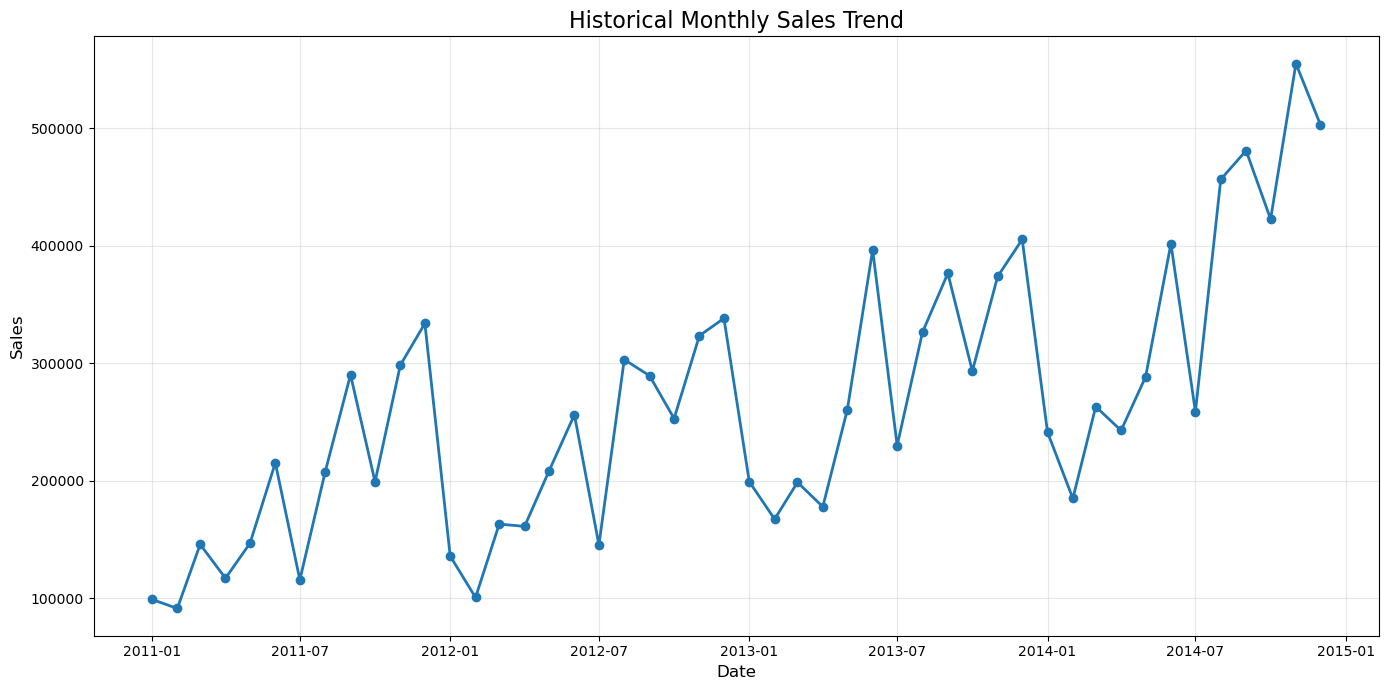

✓ Figure 1 saved


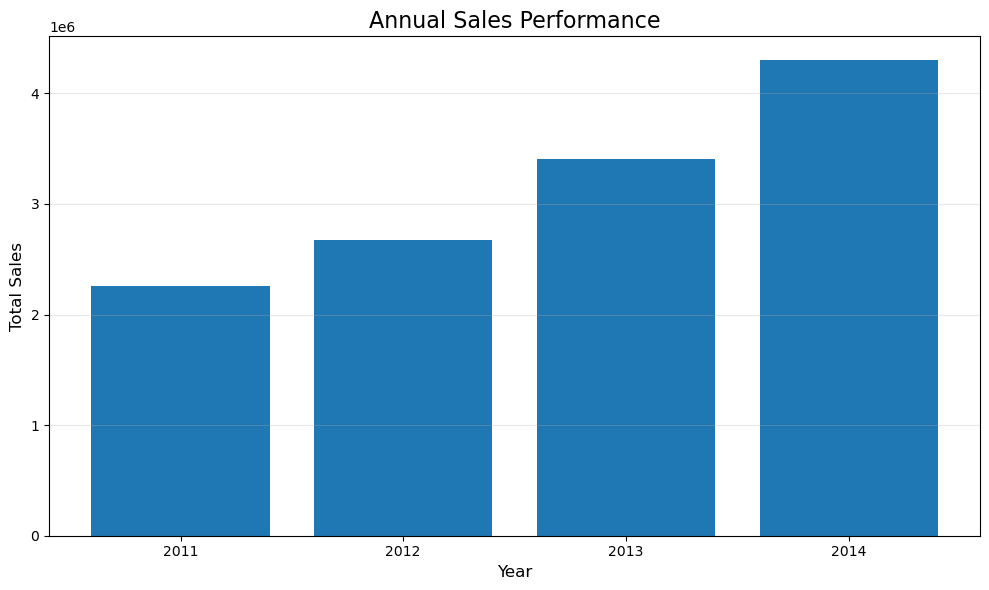

✓ Figure 2 saved


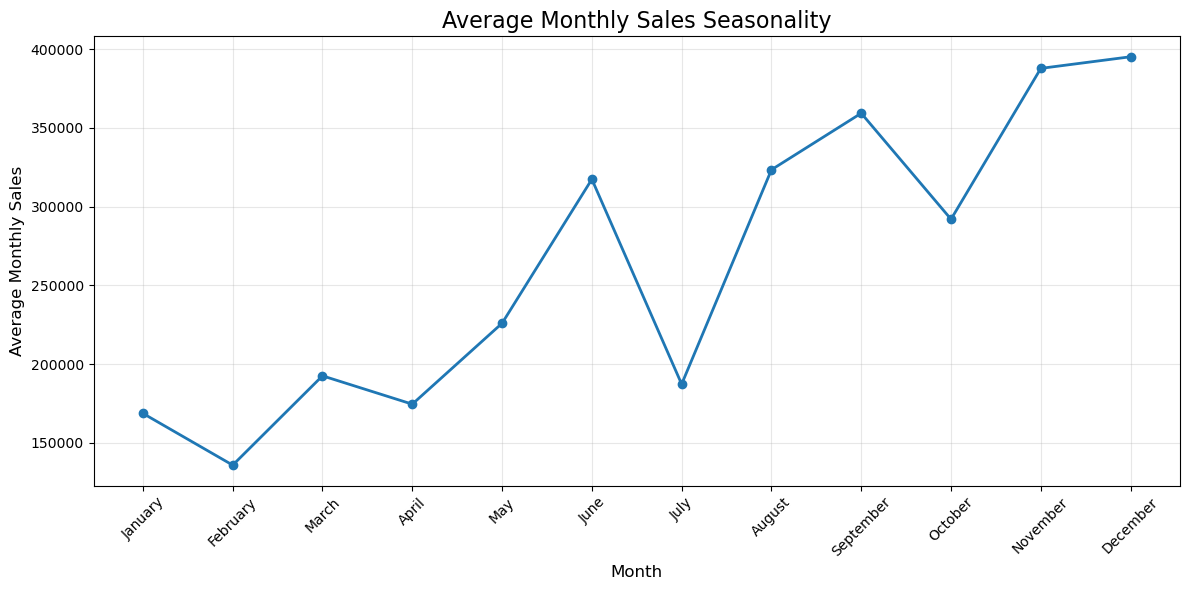

✓ Figure 3 saved


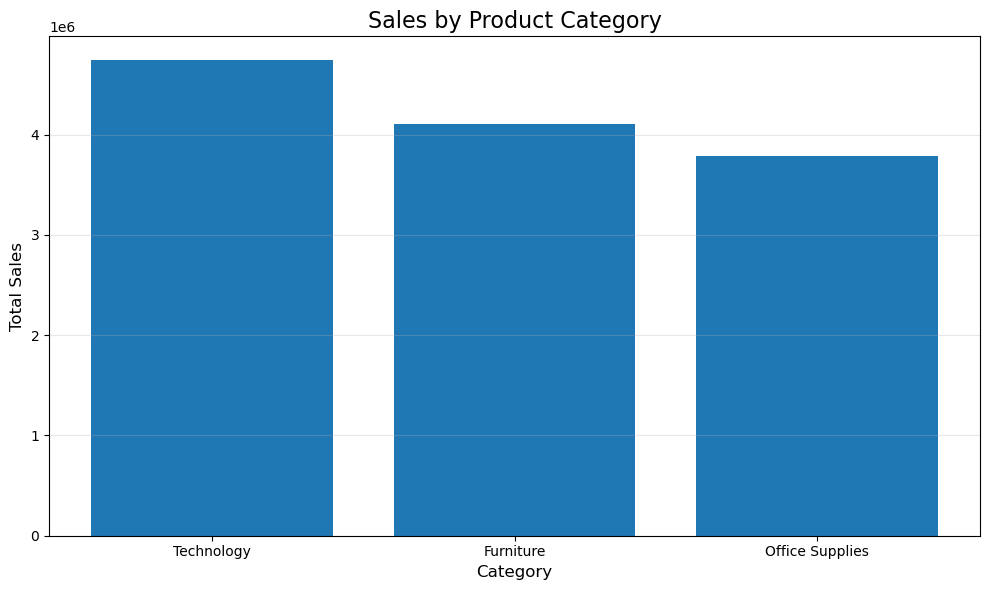

✓ Figure 4 saved


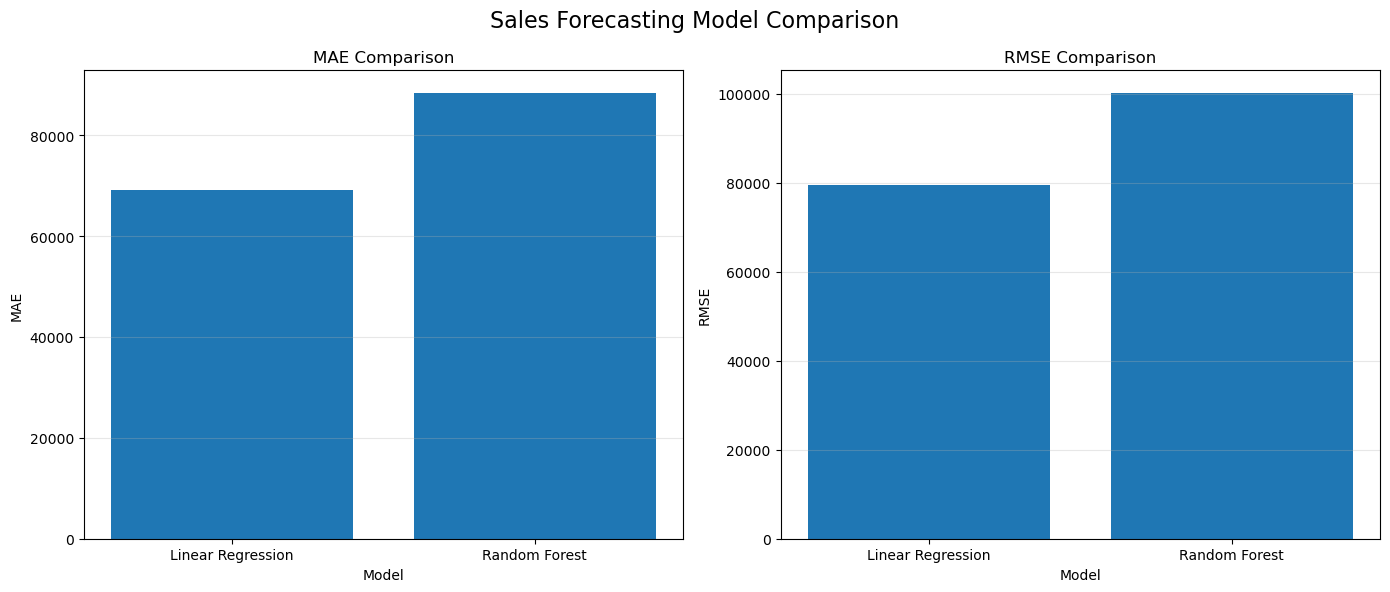

✓ Figure 5 saved


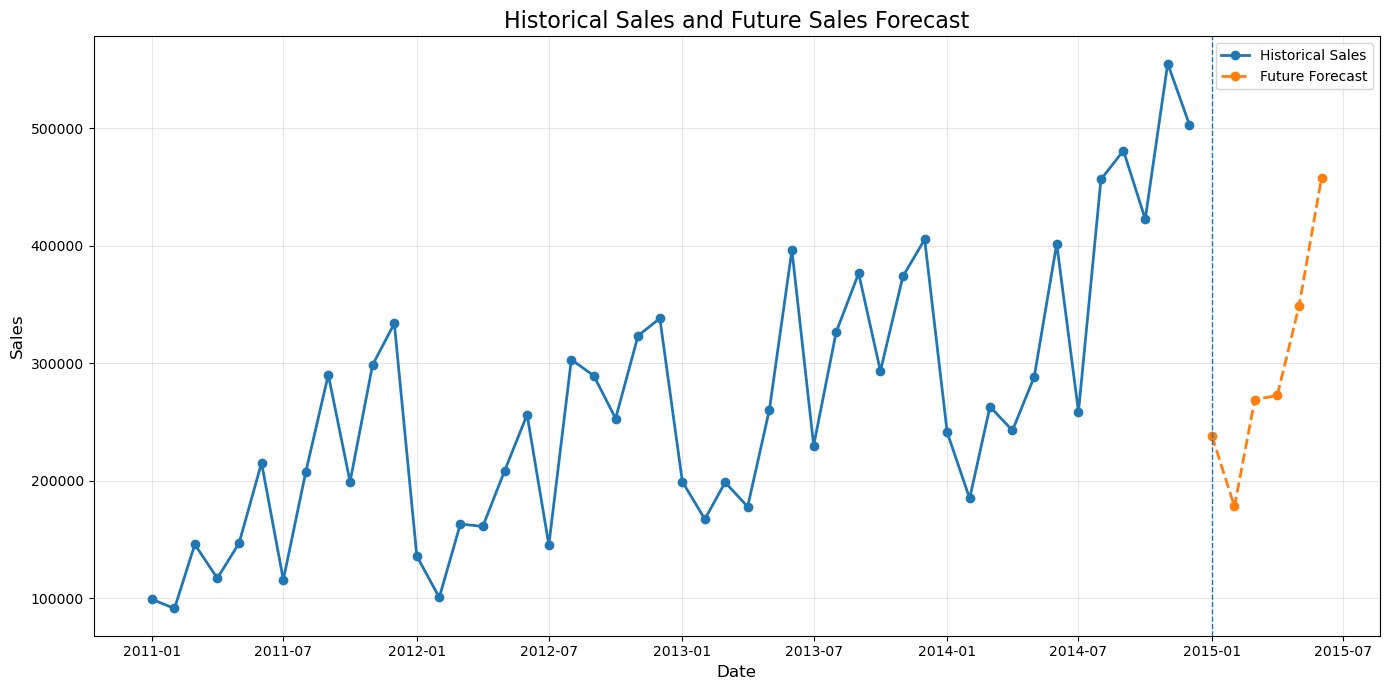

✓ Figure 6 saved

Saved Figures:
------------------------------------------------------------
✓ sales_forecasting_project\outputs\figures\01_historical_monthly_sales.png
✓ sales_forecasting_project\outputs\figures\02_yearly_sales.png
✓ sales_forecasting_project\outputs\figures\03_monthly_seasonality.png
✓ sales_forecasting_project\outputs\figures\04_category_sales.png
✓ sales_forecasting_project\outputs\figures\05_model_comparison.png
✓ sales_forecasting_project\outputs\figures\06_historical_future_forecast.png

STEP 15 COMPLETED SUCCESSFULLY


In [42]:
# ============================================================
# STEP 15: SAVE PROFESSIONAL PROJECT FIGURES
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("STEP 15: SAVING PROFESSIONAL PROJECT FIGURES")
print("=" * 60)


# ------------------------------------------------------------
# 1. Figure directory
# ------------------------------------------------------------

figure_dir = os.path.join(
    "sales_forecasting_project",
    "outputs",
    "figures"
)

os.makedirs(
    figure_dir,
    exist_ok=True
)

print("\nFigure directory:")
print(figure_dir)


# ============================================================
# FIGURE 1 — HISTORICAL MONTHLY SALES TREND
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    historical_monthly["Date"],
    historical_monthly["Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Historical Monthly Sales Trend",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Sales",
    fontsize=12
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

figure_1 = os.path.join(
    figure_dir,
    "01_historical_monthly_sales.png"
)

plt.savefig(
    figure_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 1 saved")


# ============================================================
# FIGURE 2 — YEARLY SALES
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title(
    "Annual Sales Performance",
    fontsize=16
)

plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

figure_2 = os.path.join(
    figure_dir,
    "02_yearly_sales.png"
)

plt.savefig(
    figure_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 2 saved")


# ============================================================
# FIGURE 3 — MONTHLY SEASONALITY
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Average Monthly Sales Seasonality",
    fontsize=16
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Average Monthly Sales",
    fontsize=12
)

plt.xticks(
    rotation=45
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

figure_3 = os.path.join(
    figure_dir,
    "03_monthly_seasonality.png"
)

plt.savefig(
    figure_3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 3 saved")


# ============================================================
# FIGURE 4 — CATEGORY SALES
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_sales["Category"],
    category_sales["Total Sales"]
)

plt.title(
    "Sales by Product Category",
    fontsize=16
)

plt.xlabel(
    "Category",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

figure_4 = os.path.join(
    figure_dir,
    "04_category_sales.png"
)

plt.savefig(
    figure_4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 4 saved")


# ============================================================
# FIGURE 5 — MODEL COMPARISON
# ============================================================

# MAE and RMSE comparison

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# MAE
axes[0].bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

axes[0].set_title(
    "MAE Comparison"
)

axes[0].set_xlabel(
    "Model"
)

axes[0].set_ylabel(
    "MAE"
)

axes[0].grid(
    axis="y",
    alpha=0.3
)


# RMSE
axes[1].bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

axes[1].set_title(
    "RMSE Comparison"
)

axes[1].set_xlabel(
    "Model"
)

axes[1].set_ylabel(
    "RMSE"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)


plt.suptitle(
    "Sales Forecasting Model Comparison",
    fontsize=16
)

plt.tight_layout()

figure_5 = os.path.join(
    figure_dir,
    "05_model_comparison.png"
)

plt.savefig(
    figure_5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 5 saved")


# ============================================================
# FIGURE 6 — HISTORICAL + FUTURE FORECAST
# ============================================================

plt.figure(figsize=(14, 7))


# Historical
plt.plot(
    historical_monthly["Date"],
    historical_monthly["Sales"],
    marker="o",
    linewidth=2,
    label="Historical Sales"
)


# Future forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted Sales"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Future Forecast"
)


# Forecast boundary
forecast_start = future_forecast["Date"].iloc[0]

plt.axvline(
    x=forecast_start,
    linestyle="--",
    linewidth=1
)


plt.title(
    "Historical Sales and Future Sales Forecast",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Sales",
    fontsize=12
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

figure_6 = os.path.join(
    figure_dir,
    "06_historical_future_forecast.png"
)

plt.savefig(
    figure_6,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure 6 saved")


# ============================================================
# 7. LIST ALL FIGURES
# ============================================================

print("\nSaved Figures:")
print("-" * 60)

figure_files = [
    figure_1,
    figure_2,
    figure_3,
    figure_4,
    figure_5,
    figure_6
]

for file_path in figure_files:
    print("✓", file_path)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("STEP 15 COMPLETED SUCCESSFULLY")
print("=" * 60)

In [43]:
# ============================================================
# STEP 16A: FINAL PROJECT RESULTS VERIFICATION
# ============================================================

print("=" * 70)
print("STEP 16A: FINAL PROJECT RESULTS VERIFICATION")
print("=" * 70)

print("\nPROJECT OVERVIEW")
print("-" * 70)
print("Original dataset records :", len(sales_df))
print("Original dataset columns :", 24)
print("Final forecasting records:", len(forecast_df))
print("Forecasting features     :", len(feature_columns))

print("\nDATE RANGE")
print("-" * 70)
print(
    "Historical:",
    sales_df["Order Date"].min().date(),
    "to",
    sales_df["Order Date"].max().date()
)

print(
    "Forecast:",
    future_forecast["Date"].min().date(),
    "to",
    future_forecast["Date"].max().date()
)

print("\nDATA QUALITY")
print("-" * 70)
print("Duplicate rows           :", sales_df.duplicated().sum())
print(
    "Missing values in forecast dataset:",
    forecast_df[feature_columns + [target_column]].isnull().sum().sum()
)

print("\nTRAIN / TEST")
print("-" * 70)
print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))
print("Training period      :", train_dates.min().date(), "to", train_dates.max().date())
print("Testing period       :", test_dates.min().date(), "to", test_dates.max().date())

print("\nMODEL PERFORMANCE")
print("-" * 70)
print(model_comparison.to_string(index=False))

print("\nFUTURE FORECAST")
print("-" * 70)

print(
    future_forecast[
        ["Date", "Forecasted Sales"]
    ].to_string(index=False)
)

print("\nForecast average:",
      f"${future_forecast['Forecasted Sales'].mean():,.2f}")

print("Forecast total:",
      f"${future_forecast['Forecasted Sales'].sum():,.2f}")

highest_row = future_forecast.loc[
    future_forecast["Forecasted Sales"].idxmax()
]

lowest_row = future_forecast.loc[
    future_forecast["Forecasted Sales"].idxmin()
]

print(
    "Highest forecast:",
    highest_row["Date"].strftime("%B %Y"),
    f"${highest_row['Forecasted Sales']:,.2f}"
)

print(
    "Lowest forecast:",
    lowest_row["Date"].strftime("%B %Y"),
    f"${lowest_row['Forecasted Sales']:,.2f}"
)

print("\n" + "=" * 70)
print("STEP 16A COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 16A: FINAL PROJECT RESULTS VERIFICATION

PROJECT OVERVIEW
----------------------------------------------------------------------
Original dataset records : 51290
Original dataset columns : 24
Final forecasting records: 36
Forecasting features     : 11

DATE RANGE
----------------------------------------------------------------------
Historical: 2011-01-01 to 2014-12-31
Forecast: 2015-01-01 to 2015-06-01

DATA QUALITY
----------------------------------------------------------------------
Duplicate rows           : 0
Missing values in forecast dataset: 0

TRAIN / TEST
----------------------------------------------------------------------
Training observations: 28
Testing observations : 8
Training period      : 2012-01-01 to 2014-04-01
Testing period       : 2014-05-01 to 2014-12-01

MODEL PERFORMANCE
----------------------------------------------------------------------
            Model          MAE          RMSE        R2
Linear Regression 69067.997018  79598.356175  0.314661
    